# 一、预处理阶段
这段代码是一个IMDB电影评论情感分析的数据预处理脚本，主要完成以下任务：


1. 读取IMDB数据集（训练集、测试集、无标签集）
2. 清洗文本数据（去除HTML标签、非字母字符）
3. 构建词汇表
4. 将文本转换为数值向量
5. 使用预训练的GloVe词向量初始化嵌入矩阵
6. 将处理好的数据保存为pickle文件供后续模型训练使用


In [17]:
import pandas as pd
from bs4 import BeautifulSoup
from nltk.corpus import stopwords
import re
import sys
import os
import logging
import pickle
import numpy as np
import torch
from itertools import chain
from sklearn.model_selection import train_test_split

# 读取数据
train = pd.read_csv("/kaggle/input/datasets/kintsugi0v0/imdb-data/labeledTrainData.tsv", header=0, delimiter="\t", quoting=3)
test = pd.read_csv("/kaggle/input/datasets/kintsugi0v0/imdb-data/testData.tsv", header=0, delimiter="\t", quoting=3)

# 文本清洗函数
def review_to_wordlist(review, remove_stopwords=False):
    review_text = BeautifulSoup(review, "lxml").get_text()
    review_text = re.sub("[^a-zA-Z]", " ", review_text)
    words = review_text.lower().split()
    
    if remove_stopwords:
        stops = set(stopwords.words("english"))
        words = [w for w in words if not w in stops]
    
    return words

# 日志设置
program = os.path.basename(sys.argv[0])
logger = logging.getLogger(program)
logging.basicConfig(format='%(asctime)s: %(levelname)s: %(message)s')
logging.root.setLevel(level=logging.INFO)
logger.info("running %s" % ''.join(sys.argv))

# 数据预处理
clean_train_reviews, train_labels = [], []
for i, review in enumerate(train["review"]):
    clean_train_reviews.append(review_to_wordlist(review, remove_stopwords=False))
    train_labels.append(train["sentiment"][i])

clean_test_reviews = []
for review in test["review"]:
    clean_test_reviews.append(review_to_wordlist(review, remove_stopwords=False))

print(f"clean_train_reviews 长度: {len(clean_train_reviews)}")
print(f"train_labels 长度: {len(train_labels)}")
print(f"clean_test_reviews 长度: {len(clean_test_reviews)}")

# 构建词汇表
embed_size = 300
vocab = set(chain(*clean_train_reviews)) | set(chain(*clean_test_reviews))
vocab_size = len(vocab)
print(f"词汇表大小: {vocab_size}")

# 数据划分
train_reviews, val_reviews, train_labels_split, val_labels_split = train_test_split(
    clean_train_reviews, train_labels,
    test_size=0.2, random_state=0
)

# 建立词到索引的映射
word_to_idx = {word: i + 1 for i, word in enumerate(vocab)}
word_to_idx['<unk>'] = 0
idx_to_word = {i + 1: word for i, word in enumerate(vocab)}
idx_to_word[0] = '<unk>'

# 编码函数
def encode_samples(tokenized_samples):
    features = []
    for sample in tokenized_samples:
        feature = []
        for token in sample:
            if token in word_to_idx:
                feature.append(word_to_idx[token])
            else:
                feature.append(0)
        features.append(feature)
    return features

# 填充函数
max_len = 512
def pad_samples(features, maxlen=max_len, PAD=0):
    padded_features = []
    for feature in features:
        if len(feature) >= maxlen:
            padded_feature = feature[:maxlen]
        else:
            padded_feature = feature
            while len(padded_feature) < maxlen:
                padded_feature.append(PAD)
        padded_features.append(padded_feature)
    return padded_features

# 文本编码
print("开始编码...")
train_features = torch.tensor(pad_samples(encode_samples(train_reviews)))
val_features = torch.tensor(pad_samples(encode_samples(val_reviews)))
test_features = torch.tensor(pad_samples(encode_samples(clean_test_reviews)))

train_labels_tensor = torch.tensor(train_labels_split)
val_labels_tensor = torch.tensor(val_labels_split)

print(f"train_features 形状: {train_features.shape}")
print(f"val_features 形状: {val_features.shape}")
print(f"test_features 形状: {test_features.shape}")

# ============ 优化的权重矩阵构建 ============
print("构建权重矩阵（只加载需要的词向量）...")

def load_glove_vectors_efficient(glove_file, word_to_idx, embed_size=300, cache_path=None):
    """
    高效加载 GloVe 词向量，只加载词汇表中存在的词
    """
    # 尝试从缓存加载
    if cache_path and os.path.exists(cache_path):
        print(f"从缓存加载权重矩阵: {cache_path}")
        with open(cache_path, 'rb') as f:
            return pickle.load(f)
    
    print("初始化权重矩阵...")
    weight = torch.zeros(len(word_to_idx), embed_size)
    found_words = 0
    total_needed = len(word_to_idx)
    
    print(f"开始从 GloVe 文件加载（只加载需要的词）...")
    print(f"需要匹配 {total_needed} 个词")
    
    with open(glove_file, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            # 每 200000 行显示一次进度
            if i % 200000 == 0 and i > 0:
                progress = (found_words / total_needed) * 100
                print(f"已处理 {i:,} 行, 找到 {found_words}/{total_needed} 个词 ({progress:.1f}%)")
            
            values = line.strip().split()
            word = values[0]
            
            # 只处理词汇表中存在的词
            if word in word_to_idx:
                try:
                    # 使用 .copy() 解决 non-writable 警告
                    vector = np.asarray(values[1:], dtype='float32').copy()
                    weight[word_to_idx[word], :] = torch.from_numpy(vector)
                    found_words += 1
                    
                    # 如果找到了所有需要的词，提前退出
                    if found_words == total_needed - 1:  # -1 因为 <unk>
                        print(f"✓ 已找到所有词汇表中的词!")
                        break
                except Exception as e:
                    continue
    
    print(f"加载完成: {found_words}/{total_needed} 个词 ({found_words/total_needed*100:.1f}%)")
    
    # 保存缓存以便下次使用
    if cache_path:
        print(f"保存缓存到: {cache_path}")
        with open(cache_path, 'wb') as f:
            pickle.dump(weight, f)
    
    return weight

# 使用优化的加载方法
wvmodel_file = "/kaggle/input/datasets/kintsugi0v0/glove-840b-300d-txt/glove.840B.300d.txt"
cache_file = '/kaggle/working/glove_weights_imdb.pkl'

weight = load_glove_vectors_efficient(
    wvmodel_file, 
    word_to_idx, 
    embed_size=300,
    cache_path=cache_file
)

print(f"权重矩阵形状: {weight.shape}")

# 保存数据
pickle_file = os.path.join('/kaggle/working', 'imdb_glove.pickle3')
pickle.dump(
    [train_features, train_labels_tensor, val_features, val_labels_tensor, test_features, 
     weight, word_to_idx, idx_to_word, vocab],
    open(pickle_file, 'wb')
)
print('所有数据保存成功！')

2026-07-25 20:15:54,805: INFO: running /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py-f/root/.local/share/jupyter/runtime/kernel-3e3e4a44-d098-41b0-9a4e-04cac8797497.json


clean_train_reviews 长度: 25000
train_labels 长度: 25000
clean_test_reviews 长度: 25000
词汇表大小: 101399
开始编码...
train_features 形状: torch.Size([20000, 512])
val_features 形状: torch.Size([5000, 512])
test_features 形状: torch.Size([25000, 512])
构建权重矩阵（只加载需要的词向量）...
从缓存加载权重矩阵: /kaggle/working/glove_weights_imdb.pkl
权重矩阵形状: torch.Size([101400, 300])
所有数据保存成功！


# 二、模型实现

## 2.1 CNN

In [18]:
import logging
import os
import sys
import pickle
import time

import pandas as pd
import torch
from torch import nn
from torch.nn import functional as F
from torch import optim
from torch.autograd import Variable
from tqdm import tqdm
from sklearn.metrics import accuracy_score

# ==================== 数据加载 ====================
# 读取测试数据，用于最后生成提交文件
# header=0: 第一行为列名
# delimiter="\t": tab分隔符
# quoting=3: QUOTE_NONE，不处理引号
test = pd.read_csv("/kaggle/input/datasets/kintsugi0v0/imdb-data/testData.tsv", header=0, delimiter="\t", quoting=3)

# ==================== 超参数设置 ====================
num_epochs = 10        # 训练轮数
embed_size = 300       # 词向量维度（GloVe 300维）
num_filter = 128       # 卷积核数量
filter_size = 3        # 卷积核大小（3-gram）
bidirectional = True   # 是否双向（此处未使用，预留给LSTM）
batch_size = 64        # 批量大小
labels = 2             # 分类数（正面/负面）
lr = 0.8               # 学习率
device = torch.device('cuda:0')  # 使用GPU
use_gpu = True         # GPU标志

# ==================== 模型定义 ====================
class SentimentNet(nn.Module):
    """基于TextCNN的情感分析模型"""
    def __init__(self, embed_size, num_filter, filter_size, weight, labels, use_gpu, **kwargs):
        super(SentimentNet, self).__init__(**kwargs)
        self.use_gpu = use_gpu
        
        # 使用预训练的GloVe词向量初始化embedding层
        # from_pretrained: 从预训练权重创建embedding
        self.embedding = nn.Embedding.from_pretrained(weight)
        # 冻结embedding层，不更新词向量权重
        self.embedding.weight.requires_grad = False

        # 一维卷积层
        # embed_size: 输入通道数（词向量维度）
        # num_filter: 输出通道数（卷积核数量）
        # filter_size: 卷积核大小
        # padding=1: 保持序列长度不变
        self.conv1d = nn.Conv1d(embed_size, num_filter, filter_size, padding=1)
        
        # 激活函数
        self.activate = F.relu
        
        # 全连接分类层
        # num_filter: 输入特征数（池化后的特征）
        # labels: 输出类别数
        self.decoder = nn.Linear(num_filter, labels)

    def forward(self, inputs):
        """
        前向传播
        inputs: [batch_size, seq_len] 输入序列的索引
        """
        # 词嵌入: [batch_size, seq_len, embed_size]
        embeddings = self.embedding(inputs)

        # 卷积操作: [batch_size, embed_size, seq_len] -> [batch_size, num_filter, seq_len]
        convolution = self.activate(self.conv1d(embeddings.permute([0, 2, 1])))
        
        # 最大池化: [batch_size, num_filter, seq_len] -> [batch_size, num_filter, 1]
        # kernel_size=convolution.shape[2]: 对整个序列进行池化
        pooling = F.max_pool1d(convolution, kernel_size=convolution.shape[2])

        # 全连接分类: [batch_size, num_filter] -> [batch_size, labels]
        outputs = self.decoder(pooling.squeeze(dim=2))
        
        return outputs


if __name__ == '__main__':
    # ==================== 日志配置 ====================
    # 获取当前脚本文件名
    program = os.path.basename(sys.argv[0])
    logger = logging.getLogger(program)
    # 设置日志格式：时间 - 级别 - 消息
    logging.basicConfig(format='%(asctime)s: %(levelname)s: %(message)s')
    logging.root.setLevel(level=logging.INFO)
    logger.info(r"running %s" % ''.join(sys.argv))

    # ==================== 加载预处理数据 ====================
    logging.info('loading data...')
    # 从pickle文件加载预处理好的数据
    pickle_file = '/kaggle/working/imdb_glove.pickle3'
    [train_features, train_labels, val_features, val_labels, test_features, 
     weight, word_to_idx, idx_to_word, vocab] = pickle.load(open(pickle_file, 'rb'))
    logging.info('data loaded!')

    # ==================== 初始化模型和优化器 ====================
    # 创建模型实例
    net = SentimentNet(embed_size=embed_size, num_filter=num_filter, filter_size=filter_size,
                       weight=weight, labels=labels, use_gpu=use_gpu)
    # 将模型移到GPU
    net.to(device)
    
    # 交叉熵损失函数（适用于分类任务）
    loss_function = nn.CrossEntropyLoss()
    # SGD优化器
    optimizer = optim.SGD(net.parameters(), lr=lr)

    # ==================== 创建数据加载器 ====================
    # TensorDataset: 将特征和标签打包成数据集
    train_set = torch.utils.data.TensorDataset(train_features, train_labels)
    val_set = torch.utils.data.TensorDataset(val_features, val_labels)
    test_set = torch.utils.data.TensorDataset(test_features)

    # DataLoader: 批量加载数据
    # shuffle=True: 训练集打乱顺序，验证集和测试集不需要
    train_iter = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True)
    val_iter = torch.utils.data.DataLoader(val_set, batch_size=batch_size, shuffle=False)
    test_iter = torch.utils.data.DataLoader(test_set, batch_size=batch_size, shuffle=False)

    # ==================== 训练循环 ====================
    for epoch in range(num_epochs):
        # 记录epoch开始时间
        start = time.time()
        
        # 初始化损失和准确率累加器
        train_loss, val_losses = 0, 0
        train_acc, val_acc = 0, 0
        n, m = 0, 0  # 批次计数器
        
        # tqdm: 显示进度条
        with tqdm(total=len(train_iter), desc='Epoch %d' % epoch) as pbar:
            # ---- 训练阶段 ----
            for feature, label in train_iter:
                n += 1  # 训练批次数+1
                net.zero_grad()  # 清空梯度
                
                # 将数据移到GPU并包装为Variable
                feature = Variable(feature.cuda())
                label = Variable(label.cuda())
                
                # 前向传播：计算预测分数
                score = net(feature)
                # 计算损失
                loss = loss_function(score, label)
                # 反向传播：计算梯度
                loss.backward()
                # 更新参数
                optimizer.step()
                
                # 累加准确率（取预测分数最大的类别）
                train_acc += accuracy_score(torch.argmax(score.cpu().data, dim=1), label.cpu())
                # 累加损失
                train_loss += loss

                # 更新进度条显示训练信息
                pbar.set_postfix({'epoch': '%d' % (epoch),
                                  'train loss': '%.4f' % (train_loss.data / n),
                                  'train acc': '%.2f' % (train_acc / n)
                                  })
                pbar.update(1)

            # ---- 验证阶段 ----
            with torch.no_grad():  # 不计算梯度，节省内存和计算
                for val_feature, val_label in val_iter:
                    m += 1  # 验证批次数+1
                    # 将验证数据移到GPU
                    val_feature = val_feature.cuda()
                    val_label = val_label.cuda()
                    
                    # 前向传播
                    val_score = net(val_feature)
                    # 计算验证损失
                    val_loss = loss_function(val_score, val_label)
                    
                    # 累加验证准确率和损失
                    val_acc += accuracy_score(torch.argmax(val_score.cpu().data, dim=1), val_label.cpu())
                    val_losses += val_loss
            
            # 计算运行时间
            end = time.time()
            runtime = end - start
            
            # 更新进度条显示完整信息（训练+验证）
            pbar.set_postfix({'epoch': '%d' % (epoch),
                              'train loss': '%.4f' % (train_loss.data / n),
                              'train acc': '%.2f' % (train_acc / n),
                              'val loss': '%.4f' % (val_losses.data / m),
                              'val acc': '%.2f' % (val_acc / m),
                              'time': '%.2f' % (runtime)})

    # ==================== 测试集预测 ====================
    test_pred = []  # 存储预测结果
    with torch.no_grad():  # 不计算梯度
        with tqdm(total=len(test_iter), desc='Prediction') as pbar:
            # 遍历测试数据
            for test_feature, in test_iter:  # test_iter只返回feature，没有label
                # 将测试数据移到GPU
                test_feature = test_feature.cuda()
                # 前向传播得到预测分数
                test_score = net(test_feature)
                # 取最大分数的索引作为预测类别，转换为列表并添加到结果中
                test_pred.extend(torch.argmax(test_score.cpu().data, dim=1).numpy().tolist())
                pbar.update(1)

    # ==================== 保存预测结果 ====================
    # 创建DataFrame：id和对应的情感预测
    result_output = pd.DataFrame(data={"id": test["id"], "sentiment": test_pred})
    # 保存为CSV文件
    result_output.to_csv("./cnn.csv", index=False, quoting=3)
    logging.info('result saved!')

2026-07-25 20:16:19,652: INFO: running /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py-f/root/.local/share/jupyter/runtime/kernel-3e3e4a44-d098-41b0-9a4e-04cac8797497.json
2026-07-25 20:16:19,653: INFO: loading data...
2026-07-25 20:16:20,185: INFO: data loaded!
Prediction: 100%|██████████| 391/391 [00:01<00:00, 321.40it/s]
2026-07-25 20:16:56,203: INFO: result saved!


优化：
1. 多尺度卷积用于捕获不同长度的短语
2. 微调词向量
3. Adam
4. 梯度裁剪

结果：
1. 严重过拟合

增大正则化

In [19]:
import logging
import os
import sys
import pickle
import time
import warnings

import pandas as pd
import numpy as np
import torch
from torch import nn
from torch.nn import functional as F
from torch import optim
from torch.autograd import Variable
from tqdm import tqdm
from sklearn.metrics import accuracy_score

# 忽略警告
warnings.filterwarnings('ignore')

# ==================== 数据加载 ====================
test = pd.read_csv("/kaggle/input/datasets/kintsugi0v0/imdb-data/testData.tsv", 
                   header=0, delimiter="\t", quoting=3)

# ==================== 优化后的超参数 ====================
num_epochs = 10         # 增加训练轮数
embed_size = 300        # 词向量维度
num_filter = 100        # 卷积核数量
batch_size = 64        # batch_size
labels = 2              # 分类数
lr = 0.001              # Adam使用较小的学习率
device = torch.device('cuda:0')
use_gpu = True


class SentimentNet(nn.Module):
    """多尺度TextCNN模型"""
    def __init__(self, embed_size, num_filter, weight, labels, use_gpu, **kwargs):
        super(SentimentNet, self).__init__(**kwargs)
        self.use_gpu = use_gpu
        
        # embedding层，允许微调
        self.embedding = nn.Embedding.from_pretrained(weight)
        self.embedding.weight.requires_grad = True
        
        # 多尺度卷积核
        self.conv1d_3 = nn.Conv1d(embed_size, num_filter, 3, padding=1)
        self.conv1d_4 = nn.Conv1d(embed_size, num_filter, 4, padding=2)
        self.conv1d_5 = nn.Conv1d(embed_size, num_filter, 5, padding=2)
        
        # 批归一化层
        self.bn3 = nn.BatchNorm1d(num_filter)
        self.bn4 = nn.BatchNorm1d(num_filter)
        self.bn5 = nn.BatchNorm1d(num_filter)
        
        self.dropout = nn.Dropout(0.5)
        self.activate = F.relu
        self.decoder = nn.Linear(num_filter * 3, labels)

    def forward(self, inputs):
        embeddings = self.embedding(inputs)
        x = embeddings.permute([0, 2, 1])
        
        # 多尺度卷积 + 批归一化
        conv3 = self.activate(self.bn3(self.conv1d_3(x)))
        conv4 = self.activate(self.bn4(self.conv1d_4(x)))
        conv5 = self.activate(self.bn5(self.conv1d_5(x)))
        
        # 最大池化
        pool3 = F.max_pool1d(conv3, kernel_size=conv3.shape[2]).squeeze(dim=2)
        pool4 = F.max_pool1d(conv4, kernel_size=conv4.shape[2]).squeeze(dim=2)
        pool5 = F.max_pool1d(conv5, kernel_size=conv5.shape[2]).squeeze(dim=2)
        
        # 特征拼接
        features = torch.cat([pool3, pool4, pool5], dim=1)
        features = self.dropout(features)
        outputs = self.decoder(features)
        return outputs


if __name__ == '__main__':
    # ==================== 日志配置 ====================
    program = os.path.basename(sys.argv[0])
    logger = logging.getLogger(program)
    logging.basicConfig(format='%(asctime)s: %(levelname)s: %(message)s')
    logging.root.setLevel(level=logging.INFO)
    logger.info(r"running %s" % ''.join(sys.argv))

    # ==================== 加载数据 ====================
    logging.info('loading data...')
    pickle_file = '/kaggle/working/imdb_glove.pickle3'
    [train_features, train_labels, val_features, val_labels, test_features, 
     weight, word_to_idx, idx_to_word, vocab] = pickle.load(open(pickle_file, 'rb'))
    logging.info('data loaded!')

    # ==================== 初始化模型 ====================
    net = SentimentNet(embed_size=embed_size, num_filter=num_filter,
                       weight=weight, labels=labels, use_gpu=use_gpu)
    net.to(device)
    
    # 损失函数
    loss_function = nn.CrossEntropyLoss()
    
    # Adam优化器（比SGD更快收敛）
    optimizer = optim.Adam(net.parameters(), lr=lr, weight_decay=1e-5)
    
    # 学习率调度器（移除verbose参数）
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=2
    )

    # ==================== 数据加载器 ====================
    train_set = torch.utils.data.TensorDataset(train_features, train_labels)
    val_set = torch.utils.data.TensorDataset(val_features, val_labels)
    test_set = torch.utils.data.TensorDataset(test_features)

    train_iter = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True)
    val_iter = torch.utils.data.DataLoader(val_set, batch_size=batch_size, shuffle=False)
    test_iter = torch.utils.data.DataLoader(test_set, batch_size=batch_size, shuffle=False)

    best_val_acc = 0  # 记录最佳验证准确率
    
    # ==================== 训练循环 ====================
    for epoch in range(num_epochs):
        start = time.time()
        train_loss, val_losses = 0, 0
        train_acc, val_acc = 0, 0
        n, m = 0, 0
        
        # ---- 训练阶段 ----
        net.train()  # 设置为训练模式
        with tqdm(total=len(train_iter), desc='Epoch %d' % epoch) as pbar:
            for feature, label in train_iter:
                n += 1
                net.zero_grad()
                feature = Variable(feature.cuda())
                label = Variable(label.cuda())
                score = net(feature)
                loss = loss_function(score, label)
                loss.backward()
                
                # 梯度裁剪，防止梯度爆炸
                torch.nn.utils.clip_grad_norm_(net.parameters(), max_norm=3.0)
                
                optimizer.step()
                train_acc += accuracy_score(torch.argmax(score.cpu().data, dim=1), label.cpu())
                train_loss += loss

                pbar.set_postfix({'epoch': '%d' % (epoch),
                                  'train loss': '%.4f' % (train_loss.data / n),
                                  'train acc': '%.2f' % (train_acc / n)})
                pbar.update(1)

        # ---- 验证阶段 ----
        net.eval()  # 设置为评估模式
        with torch.no_grad():
            for val_feature, val_label in val_iter:
                m += 1
                val_feature = val_feature.cuda()
                val_label = val_label.cuda()
                val_score = net(val_feature)
                val_loss = loss_function(val_score, val_label)
                val_acc += accuracy_score(torch.argmax(val_score.cpu().data, dim=1), val_label.cpu())
                val_losses += val_loss
        
        end = time.time()
        runtime = end - start
        
        # 计算平均损失和准确率
        avg_val_acc = val_acc / m
        avg_train_loss = train_loss.data / n
        avg_val_loss = val_losses.data / m
        
        # 学习率调度
        scheduler.step(avg_val_acc)
        
        # 打印当前学习率
        current_lr = optimizer.param_groups[0]['lr']
        logger.info(f'Epoch {epoch}: LR = {current_lr:.6f}')
        
        pbar.set_postfix({'epoch': '%d' % (epoch),
                          'train loss': '%.4f' % avg_train_loss,
                          'train acc': '%.2f' % (train_acc / n),
                          'val loss': '%.4f' % avg_val_loss,
                          'val acc': '%.2f' % avg_val_acc,
                          'time': '%.2f' % runtime})
        
        # 保存最佳模型
        if avg_val_acc > best_val_acc:
            best_val_acc = avg_val_acc
            torch.save(net.state_dict(), '/kaggle/working/best_model.pth')
            logger.info(f'New best model with val acc: {best_val_acc:.2%}')

    # ==================== 测试预测 ====================
    # 加载最佳模型
    net.load_state_dict(torch.load('/kaggle/working/best_model.pth'))
    net.eval()
    
    test_pred = []
    with torch.no_grad():
        with tqdm(total=len(test_iter), desc='Prediction') as pbar:
            for test_feature, in test_iter:
                test_feature = test_feature.cuda()
                test_score = net(test_feature)
                test_pred.extend(torch.argmax(test_score.cpu().data, dim=1).numpy().tolist())
                pbar.update(1)

    # ==================== 保存结果 ====================
    result_output = pd.DataFrame(data={"id": test["id"], "sentiment": test_pred})
    result_output.to_csv("./cnn_optimized.csv", index=False, quoting=3)
    logging.info('result saved!')
    print(f"Best validation accuracy: {best_val_acc:.2%}")

2026-07-25 20:16:56,613: INFO: running /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py-f/root/.local/share/jupyter/runtime/kernel-3e3e4a44-d098-41b0-9a4e-04cac8797497.json
2026-07-25 20:16:56,613: INFO: loading data...
2026-07-25 20:16:57,151: INFO: data loaded!
Epoch 0: 100%|██████████| 313/313 [00:16<00:00, 18.53it/s, epoch=0, train loss=0.7238, train acc=0.67]
2026-07-25 20:17:15,045: INFO: Epoch 0: LR = 0.001000
2026-07-25 20:17:15,268: INFO: New best model with val acc: 75.55%
Epoch 1: 100%|██████████| 313/313 [00:16<00:00, 18.53it/s, epoch=1, train loss=0.4557, train acc=0.79]
2026-07-25 20:17:33,111: INFO: Epoch 1: LR = 0.001000
2026-07-25 20:17:33,433: INFO: New best model with val acc: 85.15%
Epoch 2: 100%|██████████| 313/313 [00:16<00:00, 18.45it/s, epoch=2, train loss=0.3539, train acc=0.84]
2026-07-25 20:17:51,364: INFO: Epoch 2: LR = 0.001000
2026-07-25 20:17:51,666: INFO: New best model with val acc: 87.74%
Epoch 3: 100%|██████████| 313/313 [00:16<00:00, 

Best validation accuracy: 89.16%


## 2.2 LSTM

In [20]:
import logging
import os
import sys
import pickle
import time

import pandas as pd
import torch
from torch import nn
from torch import optim
from torch.autograd import Variable
from tqdm import tqdm

from sklearn.metrics import accuracy_score

# ==================== 数据加载 ====================
# 读取测试数据，用于最后生成提交文件
# header=0: 第一行为列名
# delimiter="\t": tab分隔符
# quoting=3: QUOTE_NONE，不处理引号
test = pd.read_csv("/kaggle/input/datasets/kintsugi0v0/imdb-data/testData.tsv", 
                   header=0, delimiter="\t", quoting=3)

# ==================== 超参数设置 ====================
num_epochs = 10        # 训练轮数
embed_size = 300       # 词向量维度（GloVe 300维）
num_hiddens = 120      # LSTM隐藏层维度
num_layers = 2         # LSTM层数
bidirectional = True   # 是否使用双向LSTM
batch_size = 64        # 批量大小
labels = 2             # 分类数（正面/负面）
lr = 0.05              # 学习率（Adam优化器）
device = torch.device('cuda:0')  # 使用GPU
use_gpu = True         # GPU标志


class SentimentNet(nn.Module):
    def __init__(self, embed_size, num_hiddens, num_layers, bidirectional, weight, labels, use_gpu, **kwargs):
        super(SentimentNet, self).__init__(**kwargs)
        self.num_hiddens = num_hiddens      # LSTM隐藏层大小
        self.num_layers = num_layers        # LSTM层数
        self.use_gpu = use_gpu              # 是否使用GPU
        self.bidirectional = bidirectional  # 是否双向
        
        # 使用预训练的GloVe词向量初始化embedding层
        self.embedding = nn.Embedding.from_pretrained(weight)
        # 冻结embedding层，不更新词向量权重
        self.embedding.weight.requires_grad = False
        
        # LSTM编码器
        # input_size: 输入特征维度（词向量维度）
        # hidden_size: 隐藏层维度
        # num_layers: LSTM层数
        # bidirectional: 是否双向
        # dropout: 层间dropout（0表示不使用）
        # 注意：当num_layers=1时，dropout参数无效
        self.encoder = nn.LSTM(input_size=embed_size, 
                               hidden_size=self.num_hiddens,
                               num_layers=num_layers, 
                               bidirectional=self.bidirectional,
                               dropout=0)
        
        # 全连接分类层
        # 如果是双向LSTM，取首尾隐藏状态拼接，维度为 num_hiddens * 4
        # 因为：前向最后状态(hidden*1) + 后向最后状态(hidden*1) = hidden*2
        #      前向最后细胞状态(hidden*1) + 后向最后细胞状态(hidden*1) = hidden*2
        #      总共 = hidden*4
        if self.bidirectional:
            self.decoder = nn.Linear(num_hiddens * 4, labels)
        else:
            # 单向LSTM：隐藏状态 + 细胞状态 = hidden*2
            self.decoder = nn.Linear(num_hiddens * 2, labels)

    def forward(self, inputs):
        """
        前向传播
        inputs: [batch_size, seq_len] 输入序列的索引
        """
        # 词嵌入: [batch_size, seq_len, embed_size]
        embeddings = self.embedding(inputs)
        
        # LSTM要求输入维度为: [seq_len, batch_size, embed_size]
        # permute([1, 0, 2]): 交换维度，将batch_size和seq_len互换
        states, hidden = self.encoder(embeddings.permute([1, 0, 2]))
        
        # states: [seq_len, batch_size, num_directions * hidden_size]
        # 取第一个时间步和最后一个时间步的隐藏状态
        # states[0]: 第一个时间步的输出
        # states[-1]: 最后一个时间步的输出
        # 对于双向LSTM，这包含了前向和后向的信息
        encoding = torch.cat([states[0], states[-1]], dim=1)
        
        # 全连接分类: [batch_size, num_hiddens*2/4] -> [batch_size, labels]
        outputs = self.decoder(encoding)
        
        return outputs


if __name__ == '__main__':
    # ==================== 日志配置 ====================
    # 获取当前脚本文件名
    program = os.path.basename(sys.argv[0])
    logger = logging.getLogger(program)
    # 设置日志格式：时间 - 级别 - 消息
    logging.basicConfig(format='%(asctime)s: %(levelname)s: %(message)s')
    logging.root.setLevel(level=logging.INFO)
    logger.info(r"running %s" % ''.join(sys.argv))

    # ==================== 加载预处理数据 ====================
    logging.info('loading data...')
    # 从pickle文件加载预处理好的数据
    pickle_file = '/kaggle/working/imdb_glove.pickle3'
    [train_features, train_labels, val_features, val_labels, test_features, 
     weight, word_to_idx, idx_to_word, vocab] = pickle.load(open(pickle_file, 'rb'))
    logging.info('data loaded!')

    # ==================== 初始化模型和优化器 ====================
    # 创建模型实例
    net = SentimentNet(embed_size=embed_size, num_hiddens=num_hiddens, 
                       num_layers=num_layers,
                       bidirectional=bidirectional, weight=weight,
                       labels=labels, use_gpu=use_gpu)
    # 将模型移到GPU
    net.to(device)
    
    # 交叉熵损失函数（适用于
    loss_function = nn.CrossEntropyLoss()
    # Adam优化器（自适应学习率，收敛更快）
    optimizer = optim.Adam(net.parameters(), lr=lr)

    # ==================== 创建数据加载器 ====================
    # TensorDataset: 将特征和标签打包成数据集
    train_set = torch.utils.data.TensorDataset(train_features, train_labels)
    val_set = torch.utils.data.TensorDataset(val_features, val_labels)
    test_set = torch.utils.data.TensorDataset(test_features)

    # DataLoader: 批量加载数据
    # shuffle=True: 训练集打乱顺序，验证集和测试集不需要
    train_iter = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True)
    val_iter = torch.utils.data.DataLoader(val_set, batch_size=batch_size, shuffle=False)
    test_iter = torch.utils.data.DataLoader(test_set, batch_size=batch_size, shuffle=False)

    # ==================== 训练循环 ====================
    for epoch in range(num_epochs):
        # 记录epoch开始时间
        start = time.time()
        
        # 初始化损失和准确率累加器
        train_loss, val_losses = 0, 0
        train_acc, val_acc = 0, 0
        n, m = 0, 0  # 批次计数器
        
        # tqdm: 显示进度条
        with tqdm(total=len(train_iter), desc='Epoch %d' % epoch) as pbar:
            # ---- 训练阶段 ----
            for feature, label in train_iter:
                n += 1  # 训练批次数+1
                net.zero_grad()  # 清空梯度
                
                # 将数据移到GPU并包装为Variable
                feature = Variable(feature.cuda())
                label = Variable(label.cuda())
                
                # 前向传播：计算预测分数
                score = net(feature)
                # 计算损失
                loss = loss_function(score, label)
                # 反向传播：计算梯度
                loss.backward()
                # 更新参数
                optimizer.step()
                
                # 累加准确率（取预测分数最大的类别）
                train_acc += accuracy_score(torch.argmax(score.cpu().data, dim=1), label.cpu())
                # 累加损失
                train_loss += loss

                # 更新进度条显示训练信息
                pbar.set_postfix({'epoch': '%d' % (epoch),
                                  'train loss': '%.4f' % (train_loss.data / n),
                                  'train acc': '%.2f' % (train_acc / n)
                                  })
                pbar.update(1)

            # ---- 验证阶段 ----
            with torch.no_grad():  # 不计算梯度，节省内存和计算
                for val_feature, val_label in val_iter:
                    m += 1  # 验证批次数+1
                    # 将验证数据移到GPU
                    val_feature = val_feature.cuda()
                    val_label = val_label.cuda()
                    
                    # 前向传播
                    val_score = net(val_feature)
                    # 计算验证损失
                    val_loss = loss_function(val_score, val_label)
                    
                    # 累加验证准确率和损失
                    val_acc += accuracy_score(torch.argmax(val_score.cpu().data, dim=1), val_label.cpu())
                    val_losses += val_loss
            
            # 计算运行时间
            end = time.time()
            runtime = end - start
            
            # 更新进度条显示完整信息（训练+验证）
            pbar.set_postfix({'epoch': '%d' % (epoch),
                              'train loss': '%.4f' % (train_loss.data / n),
                              'train acc': '%.2f' % (train_acc / n),
                              'val loss': '%.4f' % (val_losses.data / m),
                              'val acc': '%.2f' % (val_acc / m),
                              'time': '%.2f' % (runtime)
                              })

    # ==================== 测试集预测 ====================
    test_pred = []  # 存储预测结果
    with torch.no_grad():  # 不计算梯度
        with tqdm(total=len(test_iter), desc='Prediction') as pbar:
            # 遍历测试数据
            # 注意：test_iter只返回feature，没有label，所以用逗号解包
            for test_feature, in test_iter:
                # 将测试数据移到GPU
                test_feature = test_feature.cuda()
                # 前向传播得到预测分数
                test_score = net(test_feature)
                # 取最大分数的索引作为预测类别，转换为列表并添加到结果中
                test_pred.extend(torch.argmax(test_score.cpu().data, dim=1).numpy().tolist())
                pbar.update(1)

    # ==================== 保存预测结果 ====================
    # 创建DataFrame：id和对应的情感预测
    result_output = pd.DataFrame(data={"id": test["id"], "sentiment": test_pred})
    # 保存为CSV文件
    result_output.to_csv("./lstm.csv", index=False, quoting=3)
    logging.info('result saved!')

2026-07-25 20:20:03,702: INFO: running /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py-f/root/.local/share/jupyter/runtime/kernel-3e3e4a44-d098-41b0-9a4e-04cac8797497.json
2026-07-25 20:20:03,703: INFO: loading data...
2026-07-25 20:20:04,218: INFO: data loaded!
Prediction: 100%|██████████| 391/391 [00:09<00:00, 42.63it/s]
2026-07-25 20:24:24,492: INFO: result saved!


结果分析：
1. 训练不稳定，可能学习率设置过大了
2. 特征提取方式有问题？？？encoding = torch.cat([states[0], states[-1]], dim=1)

## 2.3 CNN-LSTM

In [21]:
import logging
import os
import sys
import pickle
import time

import pandas as pd
import torch
from torch import nn
from torch.nn import functional as F
from torch import optim
from torch.autograd import Variable
from tqdm import tqdm

from sklearn.metrics import accuracy_score

# ==================== 数据加载 ====================
# 读取测试数据，用于最后生成提交文件
test = pd.read_csv("/kaggle/input/datasets/kintsugi0v0/imdb-data/testData.tsv", 
                   header=0, delimiter="\t", quoting=3)

# ==================== 超参数设置 ====================
num_epochs = 10        # 训练轮数
max_len = 512          # 最大序列长度

embed_size = 300       # 词向量维度
num_filter = 128       # CNN卷积核数量
filter_size = 3        # CNN卷积核大小
pooling_size = 2       # CNN池化窗口大小

num_hiddens = 64       # LSTM隐藏层维度
num_layers = 2         # LSTM层数

bidirectional = True   # 是否使用双向LSTM
batch_size = 64        # 批量大小
labels = 2             # 分类数
lr = 0.8               # 学习率
device = torch.device('cuda:0')  # 使用GPU
use_gpu = True         # GPU标志


class SentimentNet(nn.Module):
    """CNN-LSTM混合模型"""
    def __init__(self, embed_size, num_filter, filter_size, num_hiddens, num_layers, bidirectional, weight, labels, use_gpu, **kwargs):
        super(SentimentNet, self).__init__(**kwargs)
        self.embed_size = embed_size
        self.num_filter = num_filter
        self.filter_size = filter_size
        self.num_hiddens = num_hiddens
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        self.labels = labels
        self.use_gpu = use_gpu

        # 使用预训练的GloVe词向量初始化embedding层
        self.embedding = nn.Embedding.from_pretrained(weight)
        # 冻结embedding层
        self.embedding.weight.requires_grad = False

        # CNN层：提取局部特征
        self.conv1d = nn.Conv1d(self.embed_size, self.num_filter, self.filter_size, padding=1)
        self.activate = F.relu

        # LSTM层：捕获序列依赖关系
        # 注意：CNN池化后，序列长度变为 max_len // pooling_size
        self.encoder = nn.LSTM(input_size=max_len//pooling_size, 
                              hidden_size=self.num_hiddens,
                              num_layers=self.num_layers, 
                              bidirectional=self.bidirectional,
                              dropout=0)

        # 全连接分类层
        if self.bidirectional:
            self.decoder = nn.Linear(num_hiddens * 4, labels)
        else:
            self.decoder = nn.Linear(num_hiddens * 2, labels)

    def forward(self, inputs):
        """
        前向传播
        inputs: [batch_size, seq_len]
        """
        # 词嵌入: [batch_size, seq_len, embed_size]
        embeddings = self.embedding(inputs)

        # CNN特征提取
        # permute: [batch, seq, embed] -> [batch, embed, seq]
        # conv1d: [batch, num_filter, seq_len]
        # relu激活
        convolution = self.activate(self.conv1d(embeddings.permute([0, 2, 1])))
        # 最大池化: [batch, num_filter, seq_len // pooling_size]
        pooling = F.max_pool1d(convolution, kernel_size=pooling_size)

        # LSTM序列建模
        # LSTM要求输入: [seq_len, batch_size, feature_dim]
        # permute: [batch, num_filter, pooled_len] -> [pooled_len, batch, num_filter]
        states, hidden = self.encoder(pooling.permute([1, 0, 2]))
        # 取首尾状态拼接作为最终特征
        encoding = torch.cat([states[0], states[-1]], dim=1)

        # 分类输出
        outputs = self.decoder(encoding)
        return outputs


if __name__ == '__main__':
    # ==================== 日志配置 ====================
    program = os.path.basename(sys.argv[0])
    logger = logging.getLogger(program)
    logging.basicConfig(format='%(asctime)s: %(levelname)s: %(message)s')
    logging.root.setLevel(level=logging.INFO)
    logger.info(r"running %s" % ''.join(sys.argv))

    # ==================== 加载预处理数据 ====================
    logging.info('loading data...')
    pickle_file = '/kaggle/working/imdb_glove.pickle3'
    [train_features, train_labels, val_features, val_labels, test_features, 
     weight, word_to_idx, idx_to_word, vocab] = pickle.load(open(pickle_file, 'rb'))
    logging.info('data loaded!')

    # ==================== 初始化模型 ====================
    net = SentimentNet(embed_size=embed_size, num_filter=num_filter, filter_size=filter_size,
                       num_hiddens=num_hiddens, num_layers=num_layers, bidirectional=bidirectional,
                       weight=weight, labels=labels, use_gpu=use_gpu)
    net.to(device)
    
    # 损失函数和优化器
    loss_function = nn.CrossEntropyLoss()
    optimizer = optim.SGD(net.parameters(), lr=lr)

    # ==================== 数据加载器 ====================
    train_set = torch.utils.data.TensorDataset(train_features, train_labels)
    val_set = torch.utils.data.TensorDataset(val_features, val_labels)
    test_set = torch.utils.data.TensorDataset(test_features)

    train_iter = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True)
    val_iter = torch.utils.data.DataLoader(val_set, batch_size=batch_size, shuffle=False)
    test_iter = torch.utils.data.DataLoader(test_set, batch_size=batch_size, shuffle=False)

    # ==================== 训练循环 ====================
    for epoch in range(num_epochs):
        start = time.time()
        train_loss, val_losses = 0, 0
        train_acc, val_acc = 0, 0
        n, m = 0, 0
        
        with tqdm(total=len(train_iter), desc='Epoch %d' % epoch) as pbar:
            # ---- 训练阶段 ----
            for feature, label in train_iter:
                n += 1
                net.zero_grad()
                feature = Variable(feature.cuda())
                label = Variable(label.cuda())
                score = net(feature)
                loss = loss_function(score, label)
                loss.backward()
                optimizer.step()
                train_acc += accuracy_score(torch.argmax(score.cpu().data, dim=1), label.cpu())
                train_loss += loss

                pbar.set_postfix({'epoch': '%d' % (epoch),
                                  'train loss': '%.4f' % (train_loss.data / n),
                                  'train acc': '%.2f' % (train_acc / n)})
                pbar.update(1)

            # ---- 验证阶段 ----
            with torch.no_grad():
                for val_feature, val_label in val_iter:
                    m += 1
                    val_feature = val_feature.cuda()
                    val_label = val_label.cuda()
                    val_score = net(val_feature)
                    val_loss = loss_function(val_score, val_label)
                    val_acc += accuracy_score(torch.argmax(val_score.cpu().data, dim=1), val_label.cpu())
                    val_losses += val_loss
            
            end = time.time()
            runtime = end - start
            pbar.set_postfix({'epoch': '%d' % (epoch),
                              'train loss': '%.4f' % (train_loss.data / n),
                              'train acc': '%.2f' % (train_acc / n),
                              'val loss': '%.4f' % (val_losses.data / m),
                              'val acc': '%.2f' % (val_acc / m),
                              'time': '%.2f' % (runtime)})

    # ==================== 测试集预测 ====================
    test_pred = []
    with torch.no_grad():
        with tqdm(total=len(test_iter), desc='Prediction') as pbar:
            for test_feature, in test_iter:
                test_feature = test_feature.cuda()
                test_score = net(test_feature)
                test_pred.extend(torch.argmax(test_score.cpu().data, dim=1).numpy().tolist())
                pbar.update(1)

    # ==================== 保存预测结果 ====================
    result_output = pd.DataFrame(data={"id": test["id"], "sentiment": test_pred})
    result_output.to_csv("./cnn_lstm.csv", index=False, quoting=3)
    logging.info('result saved!')

2026-07-25 20:24:24,898: INFO: running /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py-f/root/.local/share/jupyter/runtime/kernel-3e3e4a44-d098-41b0-9a4e-04cac8797497.json
2026-07-25 20:24:24,899: INFO: loading data...
2026-07-25 20:24:25,396: INFO: data loaded!
Prediction: 100%|██████████| 391/391 [00:01<00:00, 196.82it/s]
2026-07-25 20:25:21,501: INFO: result saved!


结果分析：
1. 不稳定，学习率过大？
2. 模型架构维度不对？CNN输出：[batch, 128, 256]，LSTM期望输入特征维度：256，实际上应该是：序列长度=256，特征维度=128。
3. 过拟合

优化方向：
1. 正则化
2. 学习率
3. 维度


## 2.4 Attention_LSTM

In [22]:
import logging
import os
import sys
import pickle
import time

import pandas as pd
import torch
from torch import nn
from torch import optim
from torch.nn import functional as F
from torch.autograd import Variable
from tqdm import tqdm

from sklearn.metrics import accuracy_score

# ==================== 数据加载 ====================
# 读取测试数据，用于最后生成提交文件
test = pd.read_csv("/kaggle/input/datasets/kintsugi0v0/imdb-data/testData.tsv", 
                   header=0, delimiter="\t", quoting=3)

# ==================== 超参数设置 ====================
num_epochs = 10        # 训练轮数
embed_size = 300       # 词向量维度
num_hiddens = 128      # LSTM隐藏层维度
num_layers = 2         # LSTM层数
bidirectional = True   # 是否使用双向LSTM
batch_size = 64        # 批量大小
labels = 2             # 分类数
lr = 0.01              # 学习率
device = torch.device('cuda:0')  # 使用GPU
use_gpu = True         # GPU标志


class Attention(nn.Module):
    """注意力机制模块"""
    def __init__(self, num_hiddens, bidirectional, **kwargs):
        super(Attention, self).__init__(**kwargs)
        self.num_hiddens = num_hiddens
        self.bidirectional = bidirectional

        # 如果是双向LSTM，隐藏维度翻倍
        if self.bidirectional:
            # w_omega: 将输入映射到注意力空间
            self.w_omega = nn.Parameter(torch.Tensor(num_hiddens * 2, num_hiddens * 2))
            # u_omega: 计算注意力分数
            self.u_omega = nn.Parameter(torch.Tensor(num_hiddens * 2, 1))
        else:
            self.w_omega = nn.Parameter(torch.Tensor(num_hiddens, num_hiddens))
            self.u_omega = nn.Parameter(torch.Tensor(num_hiddens, 1))

        # 使用均匀分布初始化参数
        nn.init.uniform_(self.w_omega, -0.1, 0.1)
        nn.init.uniform_(self.u_omega, -0.1, 0.1)

    def forward(self, inputs):
        """
        前向传播：计算注意力权重
        inputs: [seq_len, batch_size, num_directions * hidden_size]
        """
        x = inputs
        
        # 计算注意力分数
        # tanh(W * x): 非线性变换
        u = torch.tanh(torch.matmul(x, self.w_omega))
        # u * U: 得到每个时间步的注意力分数
        att = torch.matmul(u, self.u_omega)

        # softmax归一化得到注意力权重
        # dim=1: 在序列长度维度上归一化
        att_score = F.softmax(att, dim=1)
        
        # 加权求和：每个时间步的输出乘以对应的注意力权重
        outputs = x * att_score
        
        return outputs


class SentimentNet(nn.Module):
    """基于注意力机制的BiLSTM模型"""
    def __init__(self, embed_size, num_hiddens, num_layers, bidirectional, weight, labels, use_gpu, **kwargs):
        super(SentimentNet, self).__init__(**kwargs)
        self.embed_size = embed_size
        self.num_hiddens = num_hiddens
        self.num_layers = num_layers
        self.use_gpu = use_gpu
        self.bidirectional = bidirectional
        
        # 使用预训练的GloVe词向量初始化embedding层
        self.embedding = nn.Embedding.from_pretrained(weight)
        # 冻结embedding层，不更新词向量权重
        self.embedding.weight.requires_grad = False
        
        # LSTM编码器
        # input_size: 输入特征维度（词向量维度）
        # hidden_size: 隐藏层维度
        # num_layers: LSTM层数
        # bidirectional: 是否双向
        self.encoder = nn.LSTM(input_size=self.embed_size, 
                               hidden_size=self.num_hiddens,
                               num_layers=self.num_layers, 
                               bidirectional=self.bidirectional,
                               dropout=0)
        
        # 注意力层
        self.attention = Attention(num_hiddens=self.num_hiddens, 
                                  bidirectional=self.bidirectional)
        
        # 全连接分类层
        # 如果是双向LSTM：隐藏状态前向+后向 + 细胞状态前向+后向 = hidden*4
        if self.bidirectional:
            self.decoder = nn.Linear(num_hiddens * 4, labels)
        else:
            self.decoder = nn.Linear(num_hiddens * 2, labels)

    def forward(self, inputs):
        """
        前向传播
        inputs: [batch_size, seq_len]
        """
        # 词嵌入: [batch_size, seq_len, embed_size]
        embeddings = self.embedding(inputs)
        
        # LSTM编码
        # 输入维度: [seq_len, batch_size, embed_size]
        # states: [seq_len, batch_size, num_directions * hidden_size]
        # hidden: (h_n, c_n) 最终隐藏状态和细胞状态
        states, hidden = self.encoder(embeddings.permute(1, 0, 2))
        
        # 注意力机制：对LSTM的所有时间步输出进行加权
        # attention: [seq_len, batch_size, num_directions * hidden_size]
        attention = self.attention(states)
        
        # 取首尾时间步的注意力加权输出进行拼接
        # attention[0]: 第一个时间步的注意力输出
        # attention[-1]: 最后一个时间步的注意力输出
        encoding = torch.cat([attention[0], attention[-1]], dim=1)
        
        # 全连接分类: [batch_size, labels]
        outputs = self.decoder(encoding)
        
        return outputs


if __name__ == '__main__':
    # ==================== 日志配置 ====================
    # 获取当前脚本文件名
    program = os.path.basename(sys.argv[0])
    logger = logging.getLogger(program)
    # 设置日志格式：时间 - 级别 - 消息
    logging.basicConfig(format='%(asctime)s: %(levelname)s: %(message)s')
    logging.root.setLevel(level=logging.INFO)
    logger.info(r"running %s" % ''.join(sys.argv))

    # ==================== 加载预处理数据 ====================
    logging.info('loading data...')
    pickle_file = '/kaggle/working/imdb_glove.pickle3'
    [train_features, train_labels, val_features, val_labels, test_features, 
     weight, word_to_idx, idx_to_word, vocab] = pickle.load(open(pickle_file, 'rb'))
    logging.info('data loaded!')

    # ==================== 初始化模型和优化器 ====================
    # 创建带有注意力机制的BiLSTM模型
    net = SentimentNet(embed_size=embed_size, num_hiddens=num_hiddens, 
                       num_layers=num_layers,
                       bidirectional=bidirectional, weight=weight,
                       labels=labels, use_gpu=use_gpu)
    # 将模型移到GPU
    net.to(device)
    
    # 交叉熵损失函数（适用于分类任务）
    loss_function = nn.CrossEntropyLoss()
    # Adam优化器
    optimizer = optim.Adam(net.parameters(), lr=lr)

    # ==================== 创建数据加载器 ====================
    # TensorDataset: 将特征和标签打包成数据集
    train_set = torch.utils.data.TensorDataset(train_features, train_labels)
    val_set = torch.utils.data.TensorDataset(val_features, val_labels)
    test_set = torch.utils.data.TensorDataset(test_features)

    # DataLoader: 批量加载数据
    # shuffle=True: 训练集打乱顺序，验证集和测试集不需要
    train_iter = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True)
    val_iter = torch.utils.data.DataLoader(val_set, batch_size=batch_size, shuffle=False)
    test_iter = torch.utils.data.DataLoader(test_set, batch_size=batch_size, shuffle=False)

    # ==================== 训练循环 ====================
    for epoch in range(num_epochs):
        # 记录epoch开始时间
        start = time.time()
        
        # 初始化损失和准确率累加器
        train_loss, val_losses = 0, 0
        train_acc, val_acc = 0, 0
        n, m = 0, 0  # 批次计数器
        
        # tqdm: 显示进度条
        with tqdm(total=len(train_iter), desc='Epoch %d' % epoch) as pbar:
            # ---- 训练阶段 ----
            for feature, label in train_iter:
                n += 1  # 训练批次数+1
                net.zero_grad()  # 清空梯度
                
                # 将数据移到GPU并包装为Variable
                feature = Variable(feature.cuda())
                label = Variable(label.cuda())
                
                # 前向传播：计算预测分数
                score = net(feature)
                # 计算损失
                loss = loss_function(score, label)
                # 反向传播：计算梯度
                loss.backward()
                # 更新参数
                optimizer.step()
                
                # 累加准确率（取预测分数最大的类别）
                train_acc += accuracy_score(torch.argmax(score.cpu().data, dim=1), label.cpu())
                # 累加损失
                train_loss += loss

                # 更新进度条显示训练信息
                pbar.set_postfix({'epoch': '%d' % (epoch),
                                  'train loss': '%.4f' % (train_loss.data / n),
                                  'train acc': '%.2f' % (train_acc / n)})
                pbar.update(1)

            # ---- 验证阶段 ----
            with torch.no_grad():  # 不计算梯度，节省内存和计算
                for val_feature, val_label in val_iter:
                    m += 1  # 验证批次数+1
                    # 将验证数据移到GPU
                    val_feature = val_feature.cuda()
                    val_label = val_label.cuda()
                    
                    # 前向传播
                    val_score = net(val_feature)
                    # 计算验证损失
                    val_loss = loss_function(val_score, val_label)
                    
                    # 累加验证准确率和损失
                    val_acc += accuracy_score(torch.argmax(val_score.cpu().data, dim=1), val_label.cpu())
                    val_losses += val_loss
            
            # 计算运行时间
            end = time.time()
            runtime = end - start
            
            # 更新进度条显示完整信息（训练+验证）
            pbar.set_postfix({'epoch': '%d' % (epoch),
                              'train loss': '%.4f' % (train_loss.data / n),
                              'train acc': '%.2f' % (train_acc / n),
                              'val loss': '%.4f' % (val_losses.data / m),
                              'val acc': '%.2f' % (val_acc / m),
                              'time': '%.2f' % (runtime)})

    # ==================== 测试集预测 ====================
    test_pred = []  # 存储预测结果
    with torch.no_grad():  # 不计算梯度
        with tqdm(total=len(test_iter), desc='Prediction') as pbar:
            # 遍历测试数据
            # 注意：test_iter只返回feature，没有label，所以用逗号解包
            for test_feature, in test_iter:
                # 将测试数据移到GPU
                test_feature = test_feature.cuda()
                # 前向传播得到预测分数
                test_score = net(test_feature)
                # 取最大分数的索引作为预测类别，转换为列表并添加到结果中
                test_pred.extend(torch.argmax(test_score.cpu().data, dim=1).numpy().tolist())
                pbar.update(1)

    # ==================== 保存预测结果 ====================
    # 创建DataFrame：id和对应的情感预测
    result_output = pd.DataFrame(data={"id": test["id"], "sentiment": test_pred})
    # 保存为CSV文件
    result_output.to_csv("./attention_lstm.csv", index=False, quoting=3)
    logging.info('result saved!')

2026-07-25 20:25:21,915: INFO: running /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py-f/root/.local/share/jupyter/runtime/kernel-3e3e4a44-d098-41b0-9a4e-04cac8797497.json
2026-07-25 20:25:21,916: INFO: loading data...
2026-07-25 20:25:22,464: INFO: data loaded!
Prediction: 100%|██████████| 391/391 [00:11<00:00, 35.15it/s]
2026-07-25 20:30:09,777: INFO: result saved!


应修正注意力机制？？

## 2.5 capsule_lstm

In [23]:
import logging
import os
import sys
import pickle
import time

import pandas as pd
import torch
from torch import nn
from torch import optim
from torch.nn import functional as F
from torch.autograd import Variable
from tqdm import tqdm

from sklearn.metrics import accuracy_score

# ==================== 数据加载 ====================
test = pd.read_csv("/kaggle/input/datasets/kintsugi0v0/imdb-data/testData.tsv", 
                   header=0, delimiter="\t", quoting=3)

# ==================== 超参数设置 ====================
num_epochs = 10
embed_size = 300
num_hiddens = 128
num_layers = 2
bidirectional = True
batch_size = 64
labels = 2
lr = 0.01
device = torch.device('cuda:0')
use_gpu = True


class Capsule(nn.Module):
    """胶囊网络层"""
    def __init__(self, input_dim, num_capsule=5, dim_capsule=16, routings=4, **kwargs):
        super(Capsule, self).__init__(**kwargs)
        self.input_dim = input_dim          # 输入特征维度
        self.num_capsule = num_capsule      # 胶囊数量
        self.dim_capsule = dim_capsule      # 每个胶囊的维度
        self.routings = routings            # 动态路由迭代次数
        
        # 修复：计算总输出维度
        self.output_dim = num_capsule * dim_capsule
        
        # 转换矩阵：将输入特征映射到胶囊空间
        self.W = nn.Parameter(
            torch.randn(1, input_dim, self.output_dim) * 0.01
        )
        
    def squash(self, x, axis=-1):
        """Squash激活函数"""
        s_squared_norm = (x ** 2).sum(axis, keepdim=True)
        scale = torch.sqrt(s_squared_norm + 1e-7)
        return x / scale

    def forward(self, inputs):
        """
        inputs: [batch_size, seq_len, input_dim]
        """
        batch_size = inputs.size(0)
        seq_len = inputs.size(1)
        
        # 线性变换：[batch, seq, input_dim] @ [1, input_dim, output_dim]
        # -> [batch, seq, output_dim]
        u_hat_vecs = torch.matmul(inputs, self.W)
        
        # 重塑为 [batch, seq_len, num_capsule, dim_capsule]
        u_hat_vecs = u_hat_vecs.view(batch_size, seq_len, self.num_capsule, self.dim_capsule)
        
        # 转置为 [batch, num_capsule, seq_len, dim_capsule]
        u_hat_vecs = u_hat_vecs.permute(0, 2, 1, 3).contiguous()
        
        # 动态路由
        b = torch.zeros(batch_size, self.num_capsule, seq_len).to(inputs.device)
        
        for i in range(self.routings):
            # softmax计算耦合系数
            c = F.softmax(b, dim=1)  # [batch, num_capsule, seq_len]
            
            # 加权求和
            outputs = self.squash(torch.sum(c.unsqueeze(-1) * u_hat_vecs, dim=2))
            
            # 更新路由权重
            if i < self.routings - 1:
                b = b + torch.sum(outputs.unsqueeze(2) * u_hat_vecs, dim=-1)
        
        return outputs  # [batch, num_capsule, dim_capsule]


class SentimentNet(nn.Module):
    """BiLSTM + Capsule Network"""
    def __init__(self, embed_size, num_hiddens, num_layers, bidirectional, weight, labels, use_gpu, **kwargs):
        super(SentimentNet, self).__init__(**kwargs)
        self.embed_size = embed_size
        self.num_hiddens = num_hiddens
        self.num_layers = num_layers
        self.use_gpu = use_gpu
        self.bidirectional = bidirectional
        
        # Embedding层
        self.embedding = nn.Embedding.from_pretrained(weight)
        self.embedding.weight.requires_grad = False
        
        # BiLSTM编码器
        self.encoder = nn.LSTM(
            input_size=self.embed_size,
            hidden_size=self.num_hiddens,
            num_layers=self.num_layers,
            bidirectional=self.bidirectional,
            dropout=0,
            batch_first=True  #  使用batch_first避免维度转换
        )
        
        # 计算LSTM输出维度
        lstm_output_dim = self.num_hiddens * 2 if self.bidirectional else self.num_hiddens
        
        # 胶囊网络层
        self.capsule = Capsule(
            input_dim=lstm_output_dim,
            num_capsule=5,
            dim_capsule=16,
            routings=3
        )
        
        # 分类层：胶囊输出展平后分类
        capsule_output_dim = 5 * 16  # num_capsule * dim_capsule
        self.decoder = nn.Sequential(
            nn.Linear(capsule_output_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, labels)
        )

    def forward(self, inputs):
        """
        inputs: [batch_size, seq_len]
        """
        # 词嵌入: [batch, seq_len, embed_size]
        embeddings = self.embedding(inputs)
        
        # BiLSTM编码: [batch, seq_len, lstm_output_dim]
        states, (hidden, cell) = self.encoder(embeddings)
        
        # 胶囊网络处理: [batch, num_capsule, dim_capsule]
        capsule_output = self.capsule(states)
        
        # 展平胶囊输出: [batch, num_capsule * dim_capsule]
        flat_capsule = capsule_output.view(capsule_output.size(0), -1)
        
        # 分类
        outputs = self.decoder(flat_capsule)
        
        return outputs


if __name__ == '__main__':
    # ==================== 日志配置 ====================
    program = os.path.basename(sys.argv[0])
    logger = logging.getLogger(program)
    logging.basicConfig(format='%(asctime)s: %(levelname)s: %(message)s')
    logging.root.setLevel(level=logging.INFO)
    logger.info(r"running %s" % ''.join(sys.argv))

    # ==================== 加载数据 ====================
    logging.info('loading data...')
    pickle_file = '/kaggle/working/imdb_glove.pickle3'
    [train_features, train_labels, val_features, val_labels, test_features, 
     weight, word_to_idx, idx_to_word, vocab] = pickle.load(open(pickle_file, 'rb'))
    logging.info('data loaded!')

    # ==================== 初始化模型 ====================
    net = SentimentNet(
        embed_size=embed_size,
        num_hiddens=num_hiddens,
        num_layers=num_layers,
        bidirectional=bidirectional,
        weight=weight,
        labels=labels,
        use_gpu=use_gpu
    )
    net.to(device)
    
    loss_function = nn.CrossEntropyLoss()
    optimizer = optim.Adam(net.parameters(), lr=lr)

    # ==================== 数据加载器 ====================
    train_set = torch.utils.data.TensorDataset(train_features, train_labels)
    val_set = torch.utils.data.TensorDataset(val_features, val_labels)
    test_set = torch.utils.data.TensorDataset(test_features)

    train_iter = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True)
    val_iter = torch.utils.data.DataLoader(val_set, batch_size=batch_size, shuffle=False)
    test_iter = torch.utils.data.DataLoader(test_set, batch_size=batch_size, shuffle=False)

    # ==================== 训练循环 ====================
    for epoch in range(num_epochs):
        start = time.time()
        train_loss, val_losses = 0, 0
        train_acc, val_acc = 0, 0
        n, m = 0, 0
        
        with tqdm(total=len(train_iter), desc='Epoch %d' % epoch) as pbar:
            for feature, label in train_iter:
                n += 1
                net.zero_grad()
                feature = Variable(feature.cuda())
                label = Variable(label.cuda())
                score = net(feature)
                loss = loss_function(score, label)
                loss.backward()
                optimizer.step()
                train_acc += accuracy_score(torch.argmax(score.cpu().data, dim=1), label.cpu())
                train_loss += loss

                pbar.set_postfix({'epoch': '%d' % (epoch),
                                  'train loss': '%.4f' % (train_loss.data / n),
                                  'train acc': '%.2f' % (train_acc / n)})
                pbar.update(1)

            with torch.no_grad():
                for val_feature, val_label in val_iter:
                    m += 1
                    val_feature = val_feature.cuda()
                    val_label = val_label.cuda()
                    val_score = net(val_feature)
                    val_loss = loss_function(val_score, val_label)
                    val_acc += accuracy_score(torch.argmax(val_score.cpu().data, dim=1), val_label.cpu())
                    val_losses += val_loss
            
            end = time.time()
            runtime = end - start
            
            pbar.set_postfix({'epoch': '%d' % (epoch),
                              'train loss': '%.4f' % (train_loss.data / n),
                              'train acc': '%.2f' % (train_acc / n),
                              'val loss': '%.4f' % (val_losses.data / m),
                              'val acc': '%.2f' % (val_acc / m),
                              'time': '%.2f' % (runtime)})

    # ==================== 测试集预测 ====================
    test_pred = []
    with torch.no_grad():
        with tqdm(total=len(test_iter), desc='Prediction') as pbar:
            for test_feature, in test_iter:
                test_feature = test_feature.cuda()
                test_score = net(test_feature)
                test_pred.extend(torch.argmax(test_score.cpu().data, dim=1).numpy().tolist())
                pbar.update(1)

    # ==================== 保存预测结果 ====================
    result_output = pd.DataFrame(data={"id": test["id"], "sentiment": test_pred})
    result_output.to_csv("./capsule_lstm.csv", index=False, quoting=3)
    logging.info('result saved!')

2026-07-25 20:30:10,195: INFO: running /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py-f/root/.local/share/jupyter/runtime/kernel-3e3e4a44-d098-41b0-9a4e-04cac8797497.json
2026-07-25 20:30:10,195: INFO: loading data...
2026-07-25 20:30:10,695: INFO: data loaded!
Prediction: 100%|██████████| 391/391 [00:11<00:00, 35.32it/s]
2026-07-25 20:34:38,335: INFO: result saved!


## 2.6 GRU

In [24]:
import logging
import os
import sys
import pickle
import time

import pandas as pd
import torch
from torch import nn
from torch import optim
from torch.autograd import Variable
from tqdm import tqdm

from sklearn.metrics import accuracy_score

# ==================== 数据加载 ====================
# 读取测试数据，用于最后生成提交文件
test = pd.read_csv("/kaggle/input/datasets/kintsugi0v0/imdb-data/testData.tsv", 
                   header=0, delimiter="\t", quoting=3)

# ==================== 超参数设置 ====================
num_epochs = 10        # 训练轮数
embed_size = 300       # 词向量维度（GloVe 300维）
num_hiddens = 120      # GRU隐藏层维度
num_layers = 2         # GRU层数
bidirectional = True   # 是否使用双向GRU
batch_size = 64        # 批量大小
labels = 2             # 分类数（正面/负面）
lr = 0.8               # 学习率（SGD优化器）
device = torch.device('cuda:0')  # 使用GPU
use_gpu = True         # GPU标志


class SentimentNet(nn.Module):
    """基于BiGRU的情感分析模型"""
    def __init__(self, embed_size, num_hiddens, num_layers, bidirectional, weight, labels, use_gpu, **kwargs):
        super(SentimentNet, self).__init__(**kwargs)
        self.num_hiddens = num_hiddens      # GRU隐藏层大小
        self.num_layers = num_layers        # GRU层数
        self.use_gpu = use_gpu              # 是否使用GPU
        self.bidirectional = bidirectional  # 是否双向
        
        # 使用预训练的GloVe词向量初始化embedding层
        self.embedding = nn.Embedding.from_pretrained(weight)
        # 冻结embedding层，不更新词向量权重
        self.embedding.weight.requires_grad = False
        
        # GRU编码器（与LSTM相比，GRU只有两个门：重置门和更新门）
        # GRU比LSTM参数更少，训练更快，但在某些任务上性能略低
        self.encoder = nn.GRU(input_size=embed_size, 
                              hidden_size=self.num_hiddens,
                              num_layers=num_layers, 
                              bidirectional=self.bidirectional, 
                              dropout=0)
        
        # 全连接分类层
        # 如果是双向GRU，取首尾隐藏状态拼接，维度为 num_hiddens * 4
        # 注意：GRU只有一个隐藏状态，不像LSTM有细胞状态
        # 所以这里的 *4 实际上是：前向+后向 各取第一个和最后一个时间步 = 2 * 2 = 4
        if self.bidirectional:
            self.decoder = nn.Linear(num_hiddens * 4, labels)
        else:
            self.decoder = nn.Linear(num_hiddens * 2, labels)

    def forward(self, inputs):
        """
        前向传播
        inputs: [batch_size, seq_len] 输入序列的索引
        """
        # 词嵌入: [batch_size, seq_len, embed_size]
        embeddings = self.embedding(inputs)
        
        # GRU要求输入维度为: [seq_len, batch_size, embed_size]
        # permute([1, 0, 2]): 交换维度
        # states: [seq_len, batch_size, num_directions * hidden_size]
        # hidden: [num_layers * num_directions, batch_size, hidden_size]
        states, hidden = self.encoder(embeddings.permute([1, 0, 2]))
        
        # 取第一个时间步和最后一个时间步的隐藏状态
        # states[0]: 第一个时间步的输出（序列开始）
        # states[-1]: 最后一个时间步的输出（序列结束）
        # 对于双向GRU，这包含了前向和后向的信息
        encoding = torch.cat([states[0], states[-1]], dim=1)
        
        # 全连接分类: [batch_size, num_hiddens*4] -> [batch_size, labels]
        outputs = self.decoder(encoding)
        
        return outputs


if __name__ == '__main__':
    # ==================== 日志配置 ====================
    # 获取当前脚本文件名
    program = os.path.basename(sys.argv[0])
    logger = logging.getLogger(program)
    # 设置日志格式：时间 - 级别 - 消息
    logging.basicConfig(format='%(asctime)s: %(levelname)s: %(message)s')
    logging.root.setLevel(level=logging.INFO)
    logger.info(r"running %s" % ''.join(sys.argv))

    # ==================== 加载预处理数据 ====================
    logging.info('loading data...')
    # 从pickle文件加载预处理好的数据
    pickle_file = '/kaggle/working/imdb_glove.pickle3'
    [train_features, train_labels, val_features, val_labels, test_features, 
     weight, word_to_idx, idx_to_word, vocab] = pickle.load(open(pickle_file, 'rb'))
    logging.info('data loaded!')

    # ==================== 初始化模型和优化器 ====================
    # 创建BiGRU模型实例
    net = SentimentNet(embed_size=embed_size, num_hiddens=num_hiddens, 
                       num_layers=num_layers,
                       bidirectional=bidirectional, weight=weight,
                       labels=labels, use_gpu=use_gpu)
    # 将模型移到GPU
    net.to(device)
    
    # 交叉熵损失函数（适用于分类任务）
    loss_function = nn.CrossEntropyLoss()
    # SGD优化器（学习率0.8较大，可能导致训练不稳定）
    optimizer = optim.SGD(net.parameters(), lr=lr)

    # ==================== 创建数据加载器 ====================
    # TensorDataset: 将特征和标签打包成数据集
    train_set = torch.utils.data.TensorDataset(train_features, train_labels)
    val_set = torch.utils.data.TensorDataset(val_features, val_labels)
    test_set = torch.utils.data.TensorDataset(test_features)

    # DataLoader: 批量加载数据
    train_iter = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True)
    val_iter = torch.utils.data.DataLoader(val_set, batch_size=batch_size, shuffle=False)
    test_iter = torch.utils.data.DataLoader(test_set, batch_size=batch_size, shuffle=False)

    # ==================== 训练循环 ====================
    for epoch in range(num_epochs):
        # 记录epoch开始时间
        start = time.time()
        
        # 初始化损失和准确率累加器
        train_loss, val_losses = 0, 0
        train_acc, val_acc = 0, 0
        n, m = 0, 0  # 批次计数器
        
        # tqdm: 显示进度条
        with tqdm(total=len(train_iter), desc='Epoch %d' % epoch) as pbar:
            # ---- 训练阶段 ----
            for feature, label in train_iter:
                n += 1  # 训练批次数+1
                net.zero_grad()  # 清空梯度
                
                # 将数据移到GPU并包装为Variable
                feature = Variable(feature.cuda())
                label = Variable(label.cuda())
                
                # 前向传播：计算预测分数
                score = net(feature)
                # 计算损失
                loss = loss_function(score, label)
                # 反向传播：计算梯度
                loss.backward()
                # 更新参数
                optimizer.step()
                
                # 累加准确率（取预测分数最大的类别）
                train_acc += accuracy_score(torch.argmax(score.cpu().data, dim=1), label.cpu())
                # 累加损失
                train_loss += loss

                # 更新进度条显示训练信息
                pbar.set_postfix({'epoch': '%d' % (epoch),
                                  'train loss': '%.4f' % (train_loss.data / n),
                                  'train acc': '%.2f' % (train_acc / n)})
                pbar.update(1)

            # ---- 验证阶段 ----
            with torch.no_grad():  # 不计算梯度，节省内存和计算
                for val_feature, val_label in val_iter:
                    m += 1  # 验证批次数+1
                    # 将验证数据移到GPU
                    val_feature = val_feature.cuda()
                    val_label = val_label.cuda()
                    
                    # 前向传播
                    val_score = net(val_feature)
                    # 计算验证损失
                    val_loss = loss_function(val_score, val_label)
                    
                    # 累加验证准确率和损失
                    val_acc += accuracy_score(torch.argmax(val_score.cpu().data, dim=1), val_label.cpu())
                    val_losses += val_loss
            
            # 计算运行时间
            end = time.time()
            runtime = end - start
            
            # 更新进度条显示完整信息（训练+验证）
            pbar.set_postfix({'epoch': '%d' % (epoch),
                              'train loss': '%.4f' % (train_loss.data / n),
                              'train acc': '%.2f' % (train_acc / n),
                              'val loss': '%.4f' % (val_losses.data / m),
                              'val acc': '%.2f' % (val_acc / m),
                              'time': '%.2f' % (runtime)})

    # ==================== 测试集预测 ====================
    test_pred = []  # 存储预测结果
    with torch.no_grad():  # 不计算梯度
        with tqdm(total=len(test_iter), desc='Prediction') as pbar:
            # 遍历测试数据
            for test_feature, in test_iter:
                # 将测试数据移到GPU
                test_feature = test_feature.cuda()
                # 前向传播得到预测分数
                test_score = net(test_feature)
                # 取最大分数的索引作为预测类别
                test_pred.extend(torch.argmax(test_score.cpu().data, dim=1).numpy().tolist())
                pbar.update(1)

    # ==================== 保存预测结果 ====================
    # 创建DataFrame：id和对应的情感预测
    result_output = pd.DataFrame(data={"id": test["id"], "sentiment": test_pred})
    # 保存为CSV文件
    result_output.to_csv("./gru.csv", index=False, quoting=3)
    logging.info('result saved!')

2026-07-25 20:34:38,735: INFO: running /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py-f/root/.local/share/jupyter/runtime/kernel-3e3e4a44-d098-41b0-9a4e-04cac8797497.json
2026-07-25 20:34:38,736: INFO: loading data...
2026-07-25 20:34:39,276: INFO: data loaded!
Prediction: 100%|██████████| 391/391 [00:06<00:00, 59.86it/s]
2026-07-25 20:37:45,736: INFO: result saved!


## 2.7 Bert-native

In [1]:
import os
import sys
import logging
import time

import pandas as pd
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score
from transformers import BertTokenizerFast, BertForSequenceClassification
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# ==================== 数据加载 ====================
train = pd.read_csv("/kaggle/input/datasets/kintsugi0v0/imdb-data/labeledTrainData.tsv", 
                    header=0, delimiter="\t", quoting=3)
test = pd.read_csv("/kaggle/input/datasets/kintsugi0v0/imdb-data/testData.tsv", 
                   header=0, delimiter="\t", quoting=3)


class TrainDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels=None):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)


class TestDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, num_samples=0):
        self.encodings = encodings
        self.num_samples = num_samples

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        return item

    def __len__(self):
        return self.num_samples


if __name__ == '__main__':
    program = os.path.basename(sys.argv[0])
    logger = logging.getLogger(program)
    logging.basicConfig(format='%(asctime)s: %(levelname)s: %(message)s')
    logging.root.setLevel(level=logging.INFO)
    logger.info(r"running %s" % ''.join(sys.argv))

    # ==================== 数据预处理 ====================
    train_texts, train_labels, test_texts = [], [], []
    for i, review in enumerate(train["review"]):
        train_texts.append(review)
        train_labels.append(train['sentiment'][i])

    for review in test['review']:
        test_texts.append(review)

    train_texts, val_texts, train_labels, val_labels = train_test_split(
        train_texts, train_labels, test_size=.2
    )

    # ==================== 🔥 加速策略1：减少序列长度 ====================
    logger.info("正在加载BERT模型...")
    tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')

    # max_length=256 而不是默认的512，速度提升约2倍
    # 对于IMDb评论，256通常足够了
    train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=256)
    val_encodings = tokenizer(val_texts, truncation=True, padding=True, max_length=256)
    test_encodings = tokenizer(test_texts, truncation=True, padding=True, max_length=256)

    train_dataset = TrainDataset(train_encodings, train_labels)
    val_dataset = TrainDataset(val_encodings, val_labels)
    test_dataset = TestDataset(test_encodings, num_samples=len(test_texts))

    device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

    model = BertForSequenceClassification.from_pretrained('bert-base-uncased')
    model.to(device)
    
    # 
    scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None
    
    model.train()

    # 
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)  # 8 -> 16
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)    # 16 -> 32
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    # 
    optim = torch.optim.AdamW(model.parameters(), lr=5e-5)  

    # 
    num_epochs = 2  # BERT通常2轮就够了

    for epoch in range(num_epochs):
        start = time.time()
        train_loss, val_losses = 0, 0
        train_acc, val_acc = 0, 0
        n, m = 0, 0

        with tqdm(total=len(train_loader), desc="Epoch %d" % epoch) as pbar:
            for batch in train_loader:
                n += 1
                optim.zero_grad()
                
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)
                
                # 使用混合精度训练
                if scaler:
                    with torch.cuda.amp.autocast():
                        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
                        loss = outputs.loss
                    scaler.scale(loss).backward()
                    scaler.step(optim)
                    scaler.update()
                else:
                    outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
                    loss = outputs.loss
                    loss.backward()
                    optim.step()
                
                train_acc += accuracy_score(torch.argmax(outputs.logits.cpu().data, dim=1), labels.cpu())
                train_loss += loss.cpu()

                pbar.set_postfix({'epoch': '%d' % (epoch),
                                  'train loss': '%.4f' % (train_loss.data / n),
                                  'train acc': '%.2f' % (train_acc / n)})
                pbar.update(1)

            with torch.no_grad():
                for batch in val_loader:
                    m += 1
                    input_ids = batch['input_ids'].to(device)
                    attention_mask = batch['attention_mask'].to(device)
                    labels = batch['labels'].to(device)
                    outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
                    val_loss = outputs.loss
                    val_acc += accuracy_score(torch.argmax(outputs.logits.cpu().data, dim=1), labels.cpu())
                    val_losses += val_loss
            
            end = time.time()
            runtime = end - start
            
            pbar.set_postfix({'epoch': '%d' % (epoch),
                              'train loss': '%.4f' % (train_loss.data / n),
                              'train acc': '%.2f' % (train_acc / n),
                              'val loss': '%.4f' % (val_losses.data / m),
                              'val acc': '%.2f' % (val_acc / m),
                              'time': '%.2f' % (runtime)})

    test_pred = []
    with torch.no_grad():
        with tqdm(total=len(test_loader), desc='Predction') as pbar:
            for batch in test_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                outputs = model(input_ids, attention_mask=attention_mask)
                test_pred.extend(torch.argmax(outputs.logits.cpu().data, dim=1).numpy().tolist())
                pbar.update(1)

    result_output = pd.DataFrame(data={"id": test["id"], "sentiment": test_pred})
    result_output.to_csv("./bert_native.csv", index=False, quoting=3)
    logging.info('result saved!')

2026-07-26 00:28:36,233: INFO: running /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py-f/root/.local/share/jupyter/runtime/kernel-983bf127-ad49-4dfd-91af-912d2f2e861a.json
2026-07-26 00:28:36,359: INFO: 正在加载BERT模型...
2026-07-26 00:28:36,537: INFO: HTTP Request: HEAD https://huggingface.co/bert-base-uncased/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"
2026-07-26 00:28:36,609: INFO: HTTP Request: GET https://huggingface.co/bert-base-uncased/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"
2026-07-26 00:28:36,610: WARNING: Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

2026-07-26 00:28:36,695: INFO: HTTP Request: GET https://huggingface.co/api/models/bert-base-uncased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 307 Temporary Redirect"
2026-07-26 00:28:36,784: INFO: HTTP Request: GET https://huggingface.co/api/models/google-bert/bert-base-uncased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-07-26 00:28:36,847: INFO: HTTP Request: GET https://huggingface.co/api/models/bert-base-uncased/tree/main?recursive=true&expand=false "HTTP/1.1 307 Temporary Redirect"
2026-07-26 00:28:36,917: INFO: HTTP Request: GET https://huggingface.co/api/models/google-bert/bert-base-uncased/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
2026-07-26 00:28:36,986: INFO: HTTP Request: HEAD https://huggingface.co/bert-base-uncased/resolve/main/vocab.txt "HTTP/1.1 200 OK"
2026-07-26 00:28:37,058: INFO: HTTP Request: GET https://huggingface.co/bert-base-uncased/resolve/main/vocab.txt "HTTP/1.1 

vocab.txt: 0.00B [00:00, ?B/s]

2026-07-26 00:28:37,161: INFO: HTTP Request: HEAD https://huggingface.co/bert-base-uncased/resolve/main/tokenizer.json "HTTP/1.1 200 OK"
2026-07-26 00:28:37,230: INFO: HTTP Request: GET https://huggingface.co/bert-base-uncased/resolve/main/tokenizer.json "HTTP/1.1 200 OK"


...

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

2026-07-26 00:28:58,087: INFO: HTTP Request: HEAD https://huggingface.co/bert-base-uncased/resolve/main/adapter_config.json "HTTP/1.1 404 Not Found"
2026-07-26 00:28:58,177: INFO: HTTP Request: HEAD https://huggingface.co/bert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
2026-07-26 00:28:58,249: INFO: HTTP Request: HEAD https://huggingface.co/bert-base-uncased/resolve/main/model.safetensors "HTTP/1.1 302 Found"
2026-07-26 00:28:58,422: INFO: HTTP Request: GET https://huggingface.co/api/models/google-bert/bert-base-uncased/xet-read-token/86b5e0934494bd15c9632b12f734a8a67f723594 "HTTP/1.1 200 OK"


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/tmp/ipykernel_58/623944336.py:89: Fu

## 2.8 Bert_scratch

In [2]:
import os
import sys
import logging

import torch
import torch.nn as nn

import pandas as pd
import numpy as np

from transformers import BertTokenizerFast, DataCollatorWithPadding
from transformers import Trainer, TrainingArguments
from transformers import BertModel, BertConfig
from transformers.modeling_outputs import SequenceClassifierOutput

from sklearn.model_selection import train_test_split
from datasets import Dataset

# ==================== 数据加载 ====================
train = pd.read_csv("/kaggle/input/datasets/kintsugi0v0/imdb-data/labeledTrainData.tsv", 
                    header=0, delimiter="\t", quoting=3)
test = pd.read_csv("/kaggle/input/datasets/kintsugi0v0/imdb-data/testData.tsv", 
                   header=0, delimiter="\t", quoting=3)


# ==================== 自定义BERT分类模型 ====================
class BertScratch(nn.Module):
    """自定义BERT分类模型（使用nn.Module避免__file__错误）"""
    def __init__(self, model_name='bert-base-uncased', num_labels=2, dropout=0.1):
        super().__init__()
        self.num_labels = num_labels
        
        # 加载预训练BERT模型
        self.bert = BertModel.from_pretrained(model_name)
        
        # Dropout层
        self.dropout = nn.Dropout(dropout)
        
        # 分类头（BERT的hidden_size=768）
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_labels)
        
        # 损失函数
        self.loss_fct = nn.CrossEntropyLoss()
        
    def forward(self, input_ids=None, attention_mask=None, token_type_ids=None, labels=None):
        # 获取BERT输出
        outputs = self.bert(
            input_ids=input_ids, 
            attention_mask=attention_mask, 
            token_type_ids=token_type_ids
        )
        
        # 取[CLS] token的输出（pooled_output）
        pooled_output = outputs[1]
        
        # Dropout + 分类
        pooled_output = self.dropout(pooled_output)
        logits = self.classifier(pooled_output)
        
        # 计算损失
        loss = None
        if labels is not None:
            loss = self.loss_fct(logits.view(-1, self.num_labels), labels.view(-1))
        
        return SequenceClassifierOutput(
            loss=loss,
            logits=logits,
            hidden_states=outputs.hidden_states,
            attentions=outputs.attentions
        )


if __name__ == '__main__':
    # ==================== 日志配置 ====================
    logging.basicConfig(format='%(asctime)s: %(levelname)s: %(message)s', level=logging.INFO)
    logger = logging.getLogger(__name__)
    logger.info("running custom BERT training")

    # ==================== 数据划分 ====================
    train_data, val_data = train_test_split(train, test_size=.2)

    # ==================== 创建数据集字典 ====================
    train_dict = {'label': train_data["sentiment"].tolist(), 'text': train_data['review'].tolist()}
    val_dict = {'label': val_data["sentiment"].tolist(), 'text': val_data['review'].tolist()}
    test_dict = {"text": test['review'].tolist()}

    train_dataset = Dataset.from_dict(train_dict)
    val_dataset = Dataset.from_dict(val_dict)
    test_dataset = Dataset.from_dict(test_dict)

    # ==================== 加载BERT Tokenizer ====================
    logger.info("正在加载BERT模型...")
    tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')

    # ==================== 数据预处理 ====================
    def preprocess_function(examples):
        return tokenizer(examples['text'], truncation=True)

    tokenized_train = train_dataset.map(preprocess_function, batched=True)
    tokenized_val = val_dataset.map(preprocess_function, batched=True)
    tokenized_test = test_dataset.map(preprocess_function, batched=True)

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    # ==================== 创建模型 ====================
    model = BertScratch(model_name='bert-base-uncased', num_labels=2)

    # ==================== 评估指标 ====================
    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        predictions = np.argmax(logits, axis=-1)
        return {"accuracy": (predictions == labels).mean()}

    # ==================== 训练参数设置 ====================
    training_args = TrainingArguments(
        output_dir='./checkpoint',
        num_train_epochs=3,
        per_device_train_batch_size=6,
        per_device_eval_batch_size=12,
        warmup_steps=500,
        weight_decay=0.01,
        logging_dir='./logs',
        logging_steps=100,
        save_strategy="no",
        eval_strategy="epoch",
        learning_rate=5e-5,
    )

    # ==================== 创建Trainer ====================
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_val,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    # ==================== 开始训练 ====================
    logger.info("开始训练自定义BERT模型...")
    trainer.train()

    # ==================== 测试集预测 ====================
    logger.info("开始预测...")
    prediction_outputs = trainer.predict(tokenized_test)
    test_pred = np.argmax(prediction_outputs.predictions, axis=-1).flatten()
    print(f"预测结果示例: {test_pred[:10]}")

    # ==================== 保存预测结果 ====================
    result_output = pd.DataFrame(data={"id": test["id"], "sentiment": test_pred})
    result_output.to_csv("./bert_scratch.csv", index=False, quoting=3)
    logging.info('result saved!')

2026-07-26 00:51:34,719: INFO: TensorFlow version 2.20.0 available.
2026-07-26 00:51:34,729: INFO: JAX version 0.7.2 available.
2026-07-26 00:51:37,931: INFO: running custom BERT training
2026-07-26 00:51:38,454: INFO: 正在加载BERT模型...
2026-07-26 00:51:38,586: INFO: HTTP Request: HEAD https://huggingface.co/bert-base-uncased/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"
2026-07-26 00:51:38,653: INFO: HTTP Request: GET https://huggingface.co/api/models/bert-base-uncased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 307 Temporary Redirect"
2026-07-26 00:51:38,719: INFO: HTTP Request: GET https://huggingface.co/api/models/google-bert/bert-base-uncased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-07-26 00:51:38,784: INFO: HTTP Request: GET https://huggingface.co/api/models/bert-base-uncased/tree/main?recursive=true&expand=false "HTTP/1.1 307 Temporary Redirect"
2026-07-26 00:51:38,849: INFO: HTTP Request: GE

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

2026-07-26 00:52:02,924: INFO: HTTP Request: HEAD https://huggingface.co/bert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
2026-07-26 00:52:02,993: INFO: HTTP Request: HEAD https://huggingface.co/bert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
2026-07-26 00:52:03,068: INFO: HTTP Request: HEAD https://huggingface.co/bert-base-uncased/resolve/main/model.safetensors "HTTP/1.1 302 Found"


...

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
2026-07-26 00:52:03,685: INFO: 开始训练自定义BERT模型...
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, 

Epoch,Training Loss,Validation Loss,Accuracy
1,0.233157,0.265196,0.901200
2,0.146235,0.282456,0.928600
3,0.064211,0.346271,0.928800


2026-07-26 01:55:09,142: INFO: 开始预测...


2026-07-26 02:02:53,774: INFO: result saved!


预测结果示例: [1 0 1 0 1 1 0 0 0 1]


## 2.9 Bert_trainer

In [3]:
import os
import sys
import logging

import pandas as pd
import numpy as np

from transformers import BertTokenizerFast, BertForSequenceClassification, DataCollatorWithPadding
from transformers import Trainer, TrainingArguments
from sklearn.model_selection import train_test_split
from datasets import Dataset

# ==================== 数据加载 ====================
train = pd.read_csv("/kaggle/input/datasets/kintsugi0v0/imdb-data/labeledTrainData.tsv", 
                    header=0, delimiter="\t", quoting=3)
test = pd.read_csv("/kaggle/input/datasets/kintsugi0v0/imdb-data/testData.tsv", 
                   header=0, delimiter="\t", quoting=3)

if __name__ == '__main__':
    # ==================== 日志配置 ====================
    program = os.path.basename(sys.argv[0]) if '__file__' in dir(sys.modules['__main__']) else 'notebook'
    logger = logging.getLogger(program)
    logging.basicConfig(format='%(asctime)s: %(levelname)s: %(message)s')
    logging.root.setLevel(level=logging.INFO)
    logger.info(r"running %s" % ''.join(sys.argv))

    # ==================== 数据划分 ====================
    train_data, val_data = train_test_split(train, test_size=.2)

    # ==================== 创建数据集字典 ====================
    train_dict = {'label': train_data["sentiment"].tolist(), 'text': train_data['review'].tolist()}
    val_dict = {'label': val_data["sentiment"].tolist(), 'text': val_data['review'].tolist()}
    test_dict = {"text": test['review'].tolist()}

    train_dataset = Dataset.from_dict(train_dict)
    val_dataset = Dataset.from_dict(val_dict)
    test_dataset = Dataset.from_dict(test_dict)

    # ==================== 加载BERT Tokenizer ====================
    logger.info("正在加载BERT模型...")
    tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')

    # ==================== 数据预处理 ====================
    def preprocess_function(examples):
        return tokenizer(examples['text'], truncation=True)

    tokenized_train = train_dataset.map(preprocess_function, batched=True)
    tokenized_val = val_dataset.map(preprocess_function, batched=True)
    tokenized_test = test_dataset.map(preprocess_function, batched=True)

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    # ==================== 加载BERT模型 ====================
    model = BertForSequenceClassification.from_pretrained('bert-base-uncased')

    # ==================== 评估指标 ====================
    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        predictions = np.argmax(logits, axis=-1)
        return {"accuracy": (predictions == labels).mean()}

    # ==================== 训练参数设置 ====================
    training_args = TrainingArguments(
        output_dir='./checkpoint',
        num_train_epochs=3,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        warmup_steps=500,
        weight_decay=0.01,
        logging_dir='./logs',
        logging_steps=100,
        save_strategy="no",
        eval_strategy="epoch",  # 改为eval_strategy
        learning_rate=5e-5,     # 
    )

    # ==================== 创建Trainer ====================
    # 移除tokenizer参数
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_val,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    # ==================== 开始训练 ====================
    logger.info("开始训练BERT模型...")
    trainer.train()

    # ==================== 测试集预测 ====================
    logger.info("开始预测...")
    prediction_outputs = trainer.predict(tokenized_test)
    # 使用.predictions属性
    test_pred = np.argmax(prediction_outputs.predictions, axis=-1).flatten()
    print(f"预测结果示例: {test_pred[:10]}")

    # ==================== 保存预测结果 ====================
    result_output = pd.DataFrame(data={"id": test["id"], "sentiment": test_pred})
    result_output.to_csv("./bert_trainer.csv", index=False, quoting=3)
    logging.info('result saved!')

2026-07-26 02:04:44,247: INFO: running /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py-f/root/.local/share/jupyter/runtime/kernel-983bf127-ad49-4dfd-91af-912d2f2e861a.json
2026-07-26 02:04:44,680: INFO: 正在加载BERT模型...
2026-07-26 02:04:44,814: INFO: HTTP Request: HEAD https://huggingface.co/bert-base-uncased/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"
2026-07-26 02:04:44,881: INFO: HTTP Request: GET https://huggingface.co/api/models/bert-base-uncased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 307 Temporary Redirect"
2026-07-26 02:04:44,946: INFO: HTTP Request: GET https://huggingface.co/api/models/google-bert/bert-base-uncased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-07-26 02:04:45,010: INFO: HTTP Request: GET https://huggingface.co/api/models/bert-base-uncased/tree/main?recursive=true&expand=false "HTTP/1.1 307 Temporary Redirect"
2026-07-26 02:04:45,075: INFO: HTTP Request: G

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

2026-07-26 02:05:09,044: INFO: HTTP Request: HEAD https://huggingface.co/bert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
2026-07-26 02:05:09,123: INFO: HTTP Request: HEAD https://huggingface.co/bert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
2026-07-26 02:05:09,195: INFO: HTTP Request: HEAD https://huggingface.co/bert-base-uncased/resolve/main/model.safetensors "HTTP/1.1 302 Found"


...

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will 

Epoch,Training Loss,Validation Loss,Accuracy
1,0.477032,0.460963,0.918200
2,0.334105,0.492560,0.928600
3,0.154412,0.563246,0.935800


2026-07-26 03:01:34,360: INFO: 开始预测...


2026-07-26 03:08:49,414: INFO: result saved!


预测结果示例: [1 0 0 0 1 1 0 0 0 1]


## 2.10 Transformer

In [4]:
import logging
import os
import sys
import time
import math
import re

import pandas as pd
import torch
from torch import nn
from torch import optim
from torch.nn import functional as F
from torch.autograd import Variable
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence
from tqdm import tqdm
from bs4 import BeautifulSoup
from collections import defaultdict, Counter
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# ==================== 数据加载 ====================
test = pd.read_csv("/kaggle/input/datasets/kintsugi0v0/imdb-data/testData.tsv", 
                   header=0, delimiter="\t", quoting=3)

# ==================== 超参数设置 ====================
num_epochs = 10
embed_size = 300
num_hiddens = 120
num_layers = 2
batch_size = 64
labels = 2
lr = 0.05
device = torch.device('cuda:0')  # 使用GPU

train = pd.read_csv("/kaggle/input/datasets/kintsugi0v0/imdb-data/labeledTrainData.tsv", 
                    header=0, delimiter="\t", quoting=3)


def review_to_wordlist(review, remove_stopwords=False):
    """将评论文本转换为单词列表"""
    review_text = BeautifulSoup(review, "lxml").get_text()
    review_text = re.sub("[^a-zA-Z]", " ", review_text)
    words = review_text.lower().split()
    return words[:1000]  # 截断到1000个词


class Vocab:
    """词汇表类"""
    def __init__(self, tokens=None):
        self.idx_to_token = list()
        self.token_to_idx = dict()

        if tokens is not None:
            if "<unk>" not in tokens:
                tokens = tokens + ["<unk>"]
            for token in tokens:
                self.idx_to_token.append(token)
                self.token_to_idx[token] = len(self.idx_to_token) - 1
            self.unk = self.token_to_idx['<unk>']

    @classmethod
    def build(cls, train, test, min_freq=1, reserved_tokens=None):
        token_freqs = defaultdict(int)
        for sentence in train:
            for token in sentence:
                token_freqs[token] += 1

        for sentence in test:
            for token in sentence:
                token_freqs[token] += 1

        uniq_tokens = ["<unk>"] + (reserved_tokens if reserved_tokens else [])
        uniq_tokens += [token for token, freq in token_freqs.items() \
                        if freq >= min_freq and token != "<unk>"]
        return cls(uniq_tokens)

    def __len__(self):
        return len(self.idx_to_token)

    def __getitem__(self, token):
        return self.token_to_idx.get(token, self.unk)

    def convert_tokens_to_ids(self, tokens):
        return [self[token] for token in tokens]

    def convert_ids_to_tokens(self, indices):
        return [self.idx_to_token[index] for index in indices]


def length_to_mask(lengths):
    """根据序列长度创建mask - 确保mask在正确的设备上"""
    max_length = torch.max(lengths)
    mask = torch.arange(max_length, device=lengths.device).expand(lengths.shape[0], max_length) < lengths.unsqueeze(1)
    return mask


class PositionalEncoding(nn.Module):
    """位置编码"""
    def __init__(self, d_model, dropout=0.1, max_len=2048):
        super(PositionalEncoding, self).__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:x.size(0), :]
        return x


class Transformer(nn.Module):
    """Transformer模型"""
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_class,
                 dim_feedforward=512, num_head=2, num_layers=2, dropout=0.1, max_len=2048, activation: str = "relu"):
        super(Transformer, self).__init__()
        self.embedding_dim = embedding_dim
        self.embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.position_embedding = PositionalEncoding(embedding_dim, dropout, max_len)
        encoder_layer = nn.TransformerEncoderLayer(hidden_dim, num_head, dim_feedforward, dropout, activation)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers)
        self.output = nn.Linear(hidden_dim, num_class)

    def forward(self, inputs, lengths):
        inputs = torch.transpose(inputs, 0, 1)
        hidden_states = self.embeddings(inputs)
        hidden_states = self.position_embedding(hidden_states)
        attention_mask = length_to_mask(lengths) == False
        hidden_states = self.transformer(hidden_states, src_key_padding_mask=attention_mask)
        hidden_states = hidden_states[0, :, :]
        output = self.output(hidden_states)
        log_probs = F.log_softmax(output, dim=1)
        return log_probs


class TransformerDataset(torch.utils.data.Dataset):
    """数据集类"""
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, i):
        return self.data[i]


# 🔥 修复collate_fn - 不需要在collate_fn中移动设备
def collate_fn(examples):
    """整理函数"""
    lengths = torch.tensor([len(ex[0]) for ex in examples])
    inputs = [torch.tensor(ex[0]) for ex in examples]
    targets = torch.tensor([ex[1] for ex in examples], dtype=torch.long)
    inputs = pad_sequence(inputs, batch_first=True)
    return inputs, lengths, targets


if __name__ == '__main__':
    # ==================== 日志配置 ====================
    program = os.path.basename(sys.argv[0])
    logger = logging.getLogger(program)
    logging.basicConfig(format='%(asctime)s: %(levelname)s: %(message)s')
    logging.root.setLevel(level=logging.INFO)
    logger.info(r"running %s" % ''.join(sys.argv))

    # ==================== 数据预处理 ====================
    clean_train_reviews, train_labels = [], []
    for i, review in enumerate(train["review"]):
        clean_train_reviews.append(review_to_wordlist(review, remove_stopwords=False))
        train_labels.append(train["sentiment"][i])

    clean_test_reviews = []
    for review in test["review"]:
        clean_test_reviews.append(review_to_wordlist(review, remove_stopwords=False))

    # 构建词汇表
    vocab = Vocab.build(clean_train_reviews, clean_test_reviews)

    # 转换为索引
    train_reviews = [(vocab.convert_tokens_to_ids(sentence), train_labels[i])
                     for i, sentence in enumerate(clean_train_reviews)]
    test_reviews = [vocab.convert_tokens_to_ids(sentence)
                     for sentence in clean_test_reviews]

    train_reviews, val_reviews, train_labels, val_labels = train_test_split(
        train_reviews, train_labels, test_size=0.2, random_state=0
    )

    net = Transformer(vocab_size=len(vocab), embedding_dim=embed_size, 
                     hidden_dim=embed_size,
                     num_class=labels,
                     max_len=2048)
    net.to(device)
    loss_function = nn.CrossEntropyLoss()
    optimizer = optim.Adam(net.parameters(), lr=lr)

    # ==================== 数据加载器 ====================
    train_set = TransformerDataset(train_reviews)
    val_set = TransformerDataset(val_reviews)
    test_set = TransformerDataset(test_reviews)

    train_iter = torch.utils.data.DataLoader(train_set, collate_fn=collate_fn, 
                                            batch_size=batch_size, shuffle=True)
    val_iter = torch.utils.data.DataLoader(val_set, collate_fn=collate_fn, 
                                          batch_size=batch_size, shuffle=False)
    test_iter = torch.utils.data.DataLoader(test_set, collate_fn=collate_fn, 
                                           batch_size=batch_size, shuffle=False)

    # ==================== 训练循环 ====================
    for epoch in range(num_epochs):
        start = time.time()
        train_loss, val_losses = 0, 0
        train_acc, val_acc = 0, 0
        n, m = 0, 0
        
        with tqdm(total=len(train_iter), desc='Epoch %d' % epoch) as pbar:
            for feature, lengths, label in train_iter:
                n += 1
                net.zero_grad()
                # 确保所有张量都在同一设备上
                feature = feature.to(device)
                lengths = lengths.to(device)
                label = label.to(device)
                
                score = net(feature, lengths)
                loss = loss_function(score, label)
                loss.backward()
                optimizer.step()
                train_acc += accuracy_score(torch.argmax(score.cpu().data, dim=1), label.cpu())
                train_loss += loss

                pbar.set_postfix({'epoch': '%d' % (epoch),
                                  'train loss': '%.4f' % (train_loss.data / n),
                                  'train acc': '%.2f' % (train_acc / n)})
                pbar.update(1)

            with torch.no_grad():
                for val_feature, val_length, val_label in val_iter:
                    m += 1
                    # 确保所有张量都在同一设备上
                    val_feature = val_feature.to(device)
                    val_length = val_length.to(device)
                    val_label = val_label.to(device)
                    
                    val_score = net(val_feature, val_length)
                    val_loss = loss_function(val_score, val_label)
                    val_acc += accuracy_score(torch.argmax(val_score.cpu().data, dim=1), val_label.cpu())
                    val_losses += val_loss
            
            end = time.time()
            runtime = end - start
            
            pbar.set_postfix({'epoch': '%d' % (epoch),
                              'train loss': '%.4f' % (train_loss.data / n),
                              'train acc': '%.2f' % (train_acc / n),
                              'val loss': '%.4f' % (val_losses.data / m),
                              'val acc': '%.2f' % (val_acc / m),
                              'time': '%.2f' % (runtime)})

    # ==================== 测试集预测 ====================
    test_pred = []
    with torch.no_grad():
        with tqdm(total=len(test_iter), desc='Prediction') as pbar:
            for test_feature, test_lengths in test_iter:
                # 确保所有张量都在同一设备上
                test_feature = test_feature.to(device)
                test_lengths = test_lengths.to(device)
                
                test_score = net(test_feature, test_lengths)
                test_pred.extend(torch.argmax(test_score.cpu().data, dim=1).numpy().tolist())
                pbar.update(1)

    # ==================== 保存预测结果 ====================
    result_output = pd.DataFrame(data={"id": test["id"], "sentiment": test_pred})
    result_output.to_csv("./transformer.csv", index=False, quoting=3)
    logging.info('result saved!')

2026-07-26 03:12:08,004: INFO: running /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py-f/root/.local/share/jupyter/runtime/kernel-983bf127-ad49-4dfd-91af-912d2f2e861a.json
/tmp/ipykernel_58/1344925117.py:124: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers)
Prediction:   0%|          | 0/391 [00:00<?, ?it/s]


TypeError: object of type 'int' has no len()

## 2.11 distilbert_native

In [1]:
import os
import sys
import logging
import time

import pandas as pd
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score
from transformers import BertTokenizerFast, BertForSequenceClassification
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# ==================== 数据加载 ====================
# 读取训练和测试数据
train = pd.read_csv("/kaggle/input/datasets/kintsugi0v0/imdb-data/labeledTrainData.tsv", 
                    header=0, delimiter="\t", quoting=3)
test = pd.read_csv("/kaggle/input/datasets/kintsugi0v0/imdb-data/testData.tsv", 
                   header=0, delimiter="\t", quoting=3)


# ==================== 数据集类定义 ====================
class TrainDataset(torch.utils.data.Dataset):
    """训练和验证数据集类"""
    def __init__(self, encodings, labels=None):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)


class TestDataset(torch.utils.data.Dataset):
    """测试数据集类（不含标签）"""
    def __init__(self, encodings, num_samples=0):
        self.encodings = encodings
        self.num_samples = num_samples

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        return item

    def __len__(self):
        return self.num_samples


if __name__ == '__main__':
    # ==================== 日志配置 ====================
    program = os.path.basename(sys.argv[0])
    logger = logging.getLogger(program)
    logging.basicConfig(format='%(asctime)s: %(levelname)s: %(message)s')
    logging.root.setLevel(level=logging.INFO)
    logger.info(r"running %s" % ''.join(sys.argv))

    # ==================== 数据预处理 ====================
    train_texts, train_labels, test_texts = [], [], []
    for i, review in enumerate(train["review"]):
        train_texts.append(review)
        train_labels.append(train['sentiment'][i])

    for review in test['review']:
        test_texts.append(review)

    # 划分训练集和验证集（80%训练，20%验证）
    train_texts, val_texts, train_labels, val_labels = train_test_split(
        train_texts, train_labels, test_size=.2
    )

    # ==================== 加载BERT Tokenizer ====================
    logger.info("正在加载BERT模型...")
    tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')

    # 对文本进行编码
    train_encodings = tokenizer(train_texts, truncation=True, padding=True)
    val_encodings = tokenizer(val_texts, truncation=True, padding=True)
    test_encodings = tokenizer(test_texts, truncation=True, padding=True)

    # ==================== 创建数据集 ====================
    train_dataset = TrainDataset(train_encodings, train_labels)
    val_dataset = TrainDataset(val_encodings, val_labels)
    test_dataset = TestDataset(test_encodings, num_samples=len(test_texts))

    # ==================== 设备配置 ====================
    device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

    # ==================== 加载BERT模型 ====================
    model = BertForSequenceClassification.from_pretrained('bert-base-uncased')
    model.to(device)
    model.train()

    # ==================== 数据加载器 ====================
    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

    # ==================== 优化器 ====================
    optim = torch.optim.AdamW(model.parameters(), lr=5e-5)

    # ==================== 训练循环 ====================
    for epoch in range(2):
        start = time.time()
        train_loss, val_losses = 0, 0
        train_acc, val_acc = 0, 0
        n, m = 0, 0

        with tqdm(total=len(train_loader), desc="Epoch %d" % epoch) as pbar:
            # ---- 训练阶段 ----
            for batch in train_loader:
                n += 1
                optim.zero_grad()
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)
                outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
                loss = outputs.loss
                loss.backward()
                optim.step()
                train_acc += accuracy_score(torch.argmax(outputs.logits.cpu().data, dim=1), labels.cpu())
                train_loss += loss.cpu()

                pbar.set_postfix({'epoch': '%d' % (epoch),
                                  'train loss': '%.4f' % (train_loss.data / n),
                                  'train acc': '%.2f' % (train_acc / n)})
                pbar.update(1)

            # ---- 验证阶段 ----
            with torch.no_grad():
                for batch in val_loader:
                    m += 1
                    input_ids = batch['input_ids'].to(device)
                    attention_mask = batch['attention_mask'].to(device)
                    labels = batch['labels'].to(device)
                    outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
                    val_loss = outputs.loss
                    val_acc += accuracy_score(torch.argmax(outputs.logits.cpu().data, dim=1), labels.cpu())
                    val_losses += val_loss
            
            end = time.time()
            runtime = end - start
            
            pbar.set_postfix({'epoch': '%d' % (epoch),
                              'train loss': '%.4f' % (train_loss.data / n),
                              'train acc': '%.2f' % (train_acc / n),
                              'val loss': '%.4f' % (val_losses.data / m),
                              'val acc': '%.2f' % (val_acc / m),
                              'time': '%.2f' % (runtime)})

    # ==================== 测试集预测 ====================
    test_pred = []
    with torch.no_grad():
        with tqdm(total=len(test_loader), desc='Predction') as pbar:
            for batch in test_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                outputs = model(input_ids, attention_mask=attention_mask)
                test_pred.extend(torch.argmax(outputs.logits.cpu().data, dim=1).numpy().tolist())
                pbar.update(1)

    # ==================== 保存预测结果 ====================
    result_output = pd.DataFrame(data={"id": test["id"], "sentiment": test_pred})
    result_output.to_csv("./bert_native.csv", index=False, quoting=3)
    logging.info('result saved!')

2026-07-26 04:45:53,299: INFO: running /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py-f/root/.local/share/jupyter/runtime/kernel-e95c0112-9344-4aa0-ab34-c619df79017e.json
2026-07-26 04:45:53,437: INFO: 正在加载BERT模型...
2026-07-26 04:45:53,575: INFO: HTTP Request: HEAD https://huggingface.co/bert-base-uncased/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"
2026-07-26 04:45:53,627: INFO: HTTP Request: GET https://huggingface.co/bert-base-uncased/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"
2026-07-26 04:45:53,628: WARNING: Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

2026-07-26 04:45:53,685: INFO: HTTP Request: GET https://huggingface.co/api/models/bert-base-uncased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 307 Temporary Redirect"
2026-07-26 04:45:53,726: INFO: HTTP Request: GET https://huggingface.co/api/models/google-bert/bert-base-uncased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-07-26 04:45:53,769: INFO: HTTP Request: GET https://huggingface.co/api/models/bert-base-uncased/tree/main?recursive=true&expand=false "HTTP/1.1 307 Temporary Redirect"
2026-07-26 04:45:53,813: INFO: HTTP Request: GET https://huggingface.co/api/models/google-bert/bert-base-uncased/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
2026-07-26 04:45:53,854: INFO: HTTP Request: HEAD https://huggingface.co/bert-base-uncased/resolve/main/vocab.txt "HTTP/1.1 200 OK"
2026-07-26 04:45:53,899: INFO: HTTP Request: GET https://huggingface.co/bert-base-uncased/resolve/main/vocab.txt "HTTP/1.1 

vocab.txt: 0.00B [00:00, ?B/s]

2026-07-26 04:45:53,981: INFO: HTTP Request: HEAD https://huggingface.co/bert-base-uncased/resolve/main/tokenizer.json "HTTP/1.1 200 OK"
2026-07-26 04:45:54,024: INFO: HTTP Request: GET https://huggingface.co/bert-base-uncased/resolve/main/tokenizer.json "HTTP/1.1 200 OK"


...

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

2026-07-26 04:46:19,062: INFO: HTTP Request: HEAD https://huggingface.co/bert-base-uncased/resolve/main/adapter_config.json "HTTP/1.1 404 Not Found"
2026-07-26 04:46:19,123: INFO: HTTP Request: HEAD https://huggingface.co/bert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
2026-07-26 04:46:19,172: INFO: HTTP Request: HEAD https://huggingface.co/bert-base-uncased/resolve/main/model.safetensors "HTTP/1.1 302 Found"
2026-07-26 04:46:19,262: INFO: HTTP Request: GET https://huggingface.co/api/models/google-bert/bert-base-uncased/xet-read-token/86b5e0934494bd15c9632b12f734a8a67f723594 "HTTP/1.1 200 OK"


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Predction: 100%|██████████| 1563/1563

## 2.12 distilbert_trainer

In [2]:
import os
import sys
import logging

import pandas as pd
import numpy as np

from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification, DataCollatorWithPadding
from transformers import Trainer, TrainingArguments
from sklearn.model_selection import train_test_split
from datasets import Dataset

# ==================== 数据加载 ====================
train = pd.read_csv("/kaggle/input/datasets/kintsugi0v0/imdb-data/labeledTrainData.tsv", 
                    header=0, delimiter="\t", quoting=3)
test = pd.read_csv("/kaggle/input/datasets/kintsugi0v0/imdb-data/testData.tsv", 
                   header=0, delimiter="\t", quoting=3)

if __name__ == '__main__':
    # ==================== 日志配置 ====================
    program = os.path.basename(sys.argv[0])
    logger = logging.getLogger(program)
    logging.basicConfig(format='%(asctime)s: %(levelname)s: %(message)s')
    logging.root.setLevel(level=logging.INFO)
    logger.info(r"running %s" % ''.join(sys.argv))

    # ==================== 数据划分 ====================
    train_data, val_data = train_test_split(train, test_size=.2)

    # ==================== 创建数据集字典 ====================
    train_dict = {'label': train_data["sentiment"].tolist(), 'text': train_data['review'].tolist()}
    val_dict = {'label': val_data["sentiment"].tolist(), 'text': val_data['review'].tolist()}
    test_dict = {"text": test['review'].tolist()}

    train_dataset = Dataset.from_dict(train_dict)
    val_dataset = Dataset.from_dict(val_dict)
    test_dataset = Dataset.from_dict(test_dict)

    # ==================== 加载DistilBERT Tokenizer ====================
    logger.info("正在加载DistilBERT模型...")
    tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

    # ==================== 数据预处理 ====================
    def preprocess_function(examples):
        return tokenizer(examples['text'], truncation=True)

    tokenized_train = train_dataset.map(preprocess_function, batched=True)
    tokenized_val = val_dataset.map(preprocess_function, batched=True)
    tokenized_test = test_dataset.map(preprocess_function, batched=True)

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    # ==================== 加载DistilBERT模型 ====================
    model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased')

    # ==================== 评估指标 ====================
    try:
        import evaluate
        metric = evaluate.load("accuracy")
        
        def compute_metrics(eval_pred):
            logits, labels = eval_pred
            predictions = np.argmax(logits, axis=-1)
            return metric.compute(predictions=predictions, references=labels)
    except:
        def compute_metrics(eval_pred):
            logits, labels = eval_pred
            predictions = np.argmax(logits, axis=-1)
            return {"accuracy": (predictions == labels).mean()}

    # ==================== 训练参数设置 ====================
    training_args = TrainingArguments(
        output_dir='./results',
        num_train_epochs=3,
        per_device_train_batch_size=12,
        per_device_eval_batch_size=24,
        warmup_steps=500,
        weight_decay=0.01,
        logging_dir='./logs',
        logging_steps=100,
        save_strategy="no",
        eval_strategy="epoch",
        learning_rate=5e-5,
    )

    # ==================== 创建Trainer ====================
    # 移除tokenizer参数
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_val,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    # ==================== 开始训练 ====================
    logger.info("开始训练DistilBERT模型...")
    trainer.train()

    # ==================== 测试集预测 ====================
    logger.info("开始预测...")
    prediction_outputs = trainer.predict(tokenized_test)
    test_pred = np.argmax(prediction_outputs.predictions, axis=-1).flatten()
    print(f"预测结果示例: {test_pred[:10]}")

    # ==================== 保存预测结果 ====================
    result_output = pd.DataFrame(data={"id": test["id"], "sentiment": test_pred})
    result_output.to_csv("./distilbert_trainer.csv", index=False, quoting=3)
    logging.info('result saved!')

2026-07-26 06:20:04,531: INFO: TensorFlow version 2.20.0 available.
2026-07-26 06:20:04,538: INFO: JAX version 0.7.2 available.
2026-07-26 06:20:07,688: INFO: running /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py-f/root/.local/share/jupyter/runtime/kernel-e95c0112-9344-4aa0-ab34-c619df79017e.json
2026-07-26 06:20:08,248: INFO: 正在加载DistilBERT模型...
2026-07-26 06:20:08,333: INFO: HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"
2026-07-26 06:20:08,376: INFO: HTTP Request: GET https://huggingface.co/distilbert-base-uncased/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

2026-07-26 06:20:08,430: INFO: HTTP Request: GET https://huggingface.co/api/models/distilbert-base-uncased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 307 Temporary Redirect"
2026-07-26 06:20:08,473: INFO: HTTP Request: GET https://huggingface.co/api/models/distilbert/distilbert-base-uncased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-07-26 06:20:08,514: INFO: HTTP Request: GET https://huggingface.co/api/models/distilbert-base-uncased/tree/main?recursive=true&expand=false "HTTP/1.1 307 Temporary Redirect"
2026-07-26 06:20:08,555: INFO: HTTP Request: GET https://huggingface.co/api/models/distilbert/distilbert-base-uncased/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
2026-07-26 06:20:08,597: INFO: HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/vocab.txt "HTTP/1.1 200 OK"
2026-07-26 06:20:08,638: INFO: HTTP Request: GET https://huggingface.co/distilbert-base-uncased

vocab.txt: 0.00B [00:00, ?B/s]

2026-07-26 06:20:08,718: INFO: HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/tokenizer.json "HTTP/1.1 200 OK"
2026-07-26 06:20:08,803: INFO: HTTP Request: GET https://huggingface.co/distilbert-base-uncased/resolve/main/tokenizer.json "HTTP/1.1 200 OK"


...

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
2026-07-26 06:20:37,755: INFO: 开始训练DistilBERT模型...
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarn

Epoch,Training Loss,Validation Loss,Accuracy
1,0.503782,0.446593,0.915800
2,0.344529,0.511009,0.926600
3,0.121977,0.618256,0.930200


2026-07-26 06:51:41,914: INFO: 开始预测...


2026-07-26 06:55:34,518: INFO: result saved!


预测结果示例: [1 0 0 0 1 1 0 0 0 1]


/tmp/ipykernel_58/1824072953.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(models, rotation=45, ha='right', fontsize=9)
/tmp/ipykernel_58/1824072953.py:59: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(models, rotation=45, ha='right', fontsize=9)
/tmp/ipykernel_58/1824072953.py:79: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(models, rotation=45, ha='right', fontsize=9)
/tmp/ipykernel_58/1824072953.py:97: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax4.set_xticklabels(models, rotation=45, ha='right', fontsize=9)


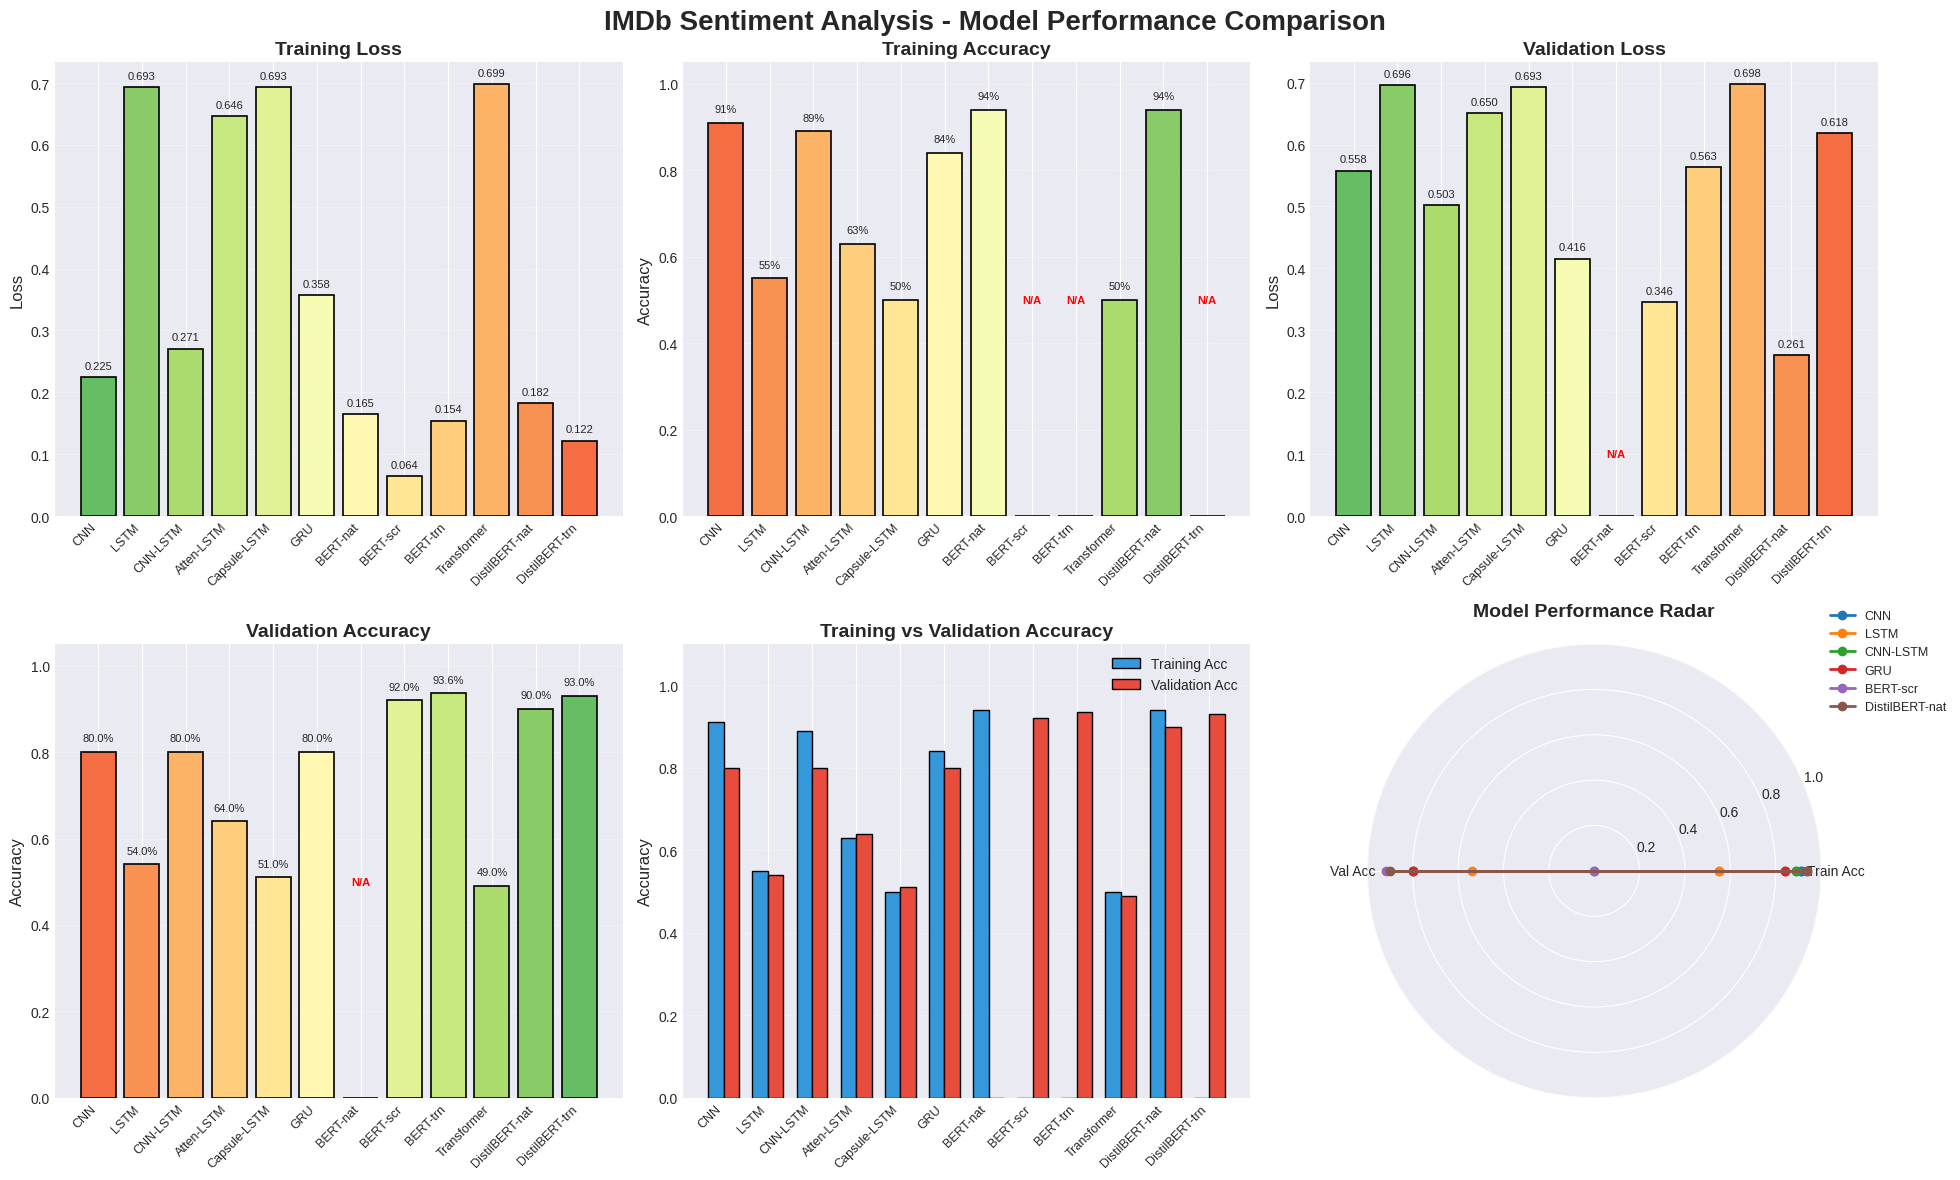

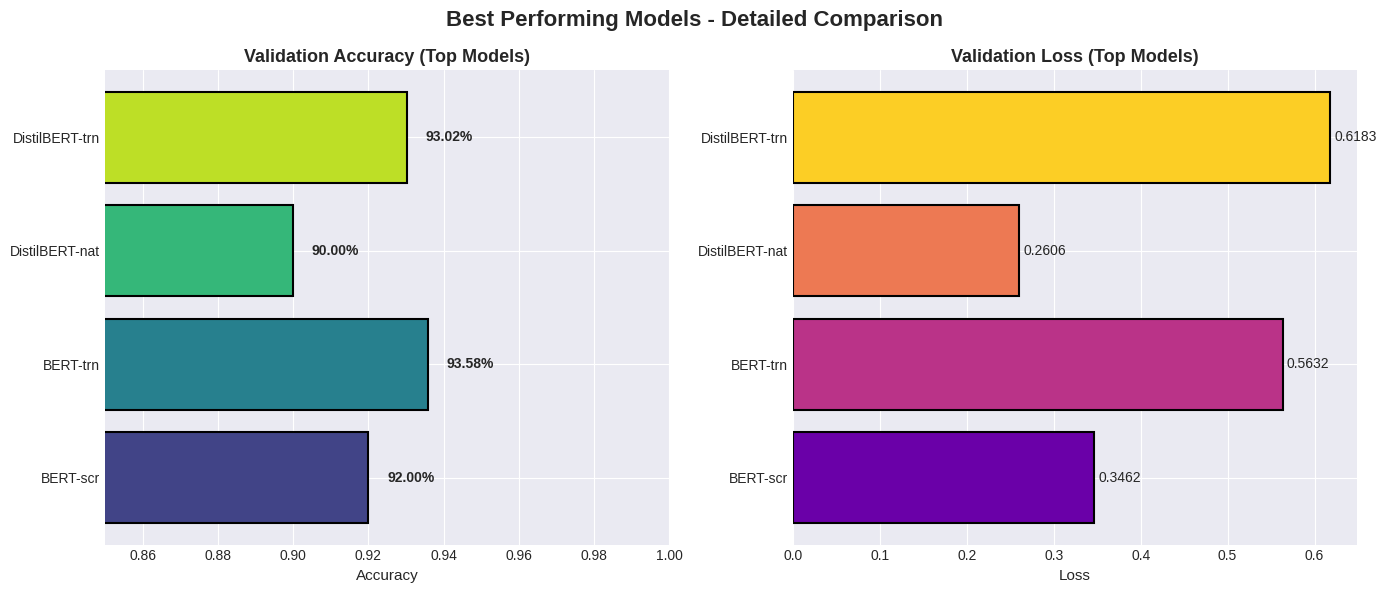

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 设置中文字体和样式
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']  # 使用英文显示
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-darkgrid')

# ==================== 数据准备 ====================
models = ['CNN', 'LSTM', 'CNN-LSTM', 'Atten-LSTM', 'Capsule-LSTM', 
          'GRU', 'BERT-nat', 'BERT-scr', 'BERT-trn', 'Transformer',
          'DistilBERT-nat', 'DistilBERT-trn']

train_loss = [0.2246, 0.6929, 0.2707, 0.6462, 0.6934, 0.3576, 
              0.1647, 0.0642, 0.1544, 0.6986, 0.1825, 0.1220]

train_acc = [0.91, 0.55, 0.89, 0.63, 0.50, 0.84, 
             0.94, None, None, 0.50, 0.94, None]

val_loss = [0.5581, 0.6955, 0.5027, 0.6502, 0.6930, 0.4159,
            None, 0.3462, 0.5632, 0.6979, 0.2606, 0.6183]

val_acc = [0.80, 0.54, 0.80, 0.64, 0.51, 0.80,
           None, 0.92, 0.9358, 0.49, 0.90, 0.9302]

# 处理None值（用于绘图时跳过）
train_acc_plot = [x if x is not None else 0 for x in train_acc]
val_loss_plot = [x if x is not None else 0 for x in val_loss]
val_acc_plot = [x if x is not None else 0 for x in val_acc]

# ==================== 创建大图 ====================
fig = plt.figure(figsize=(20, 12))
fig.suptitle('IMDb Sentiment Analysis - Model Performance Comparison', 
             fontsize=20, fontweight='bold', y=0.98)

# ===== 1. 训练损失对比 =====
ax1 = plt.subplot(2, 3, 1)
colors1 = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(models)))
bars1 = ax1.bar(models, train_loss, color=colors1, edgecolor='black', linewidth=1.2)
ax1.set_title('Training Loss', fontsize=14, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_xticklabels(models, rotation=45, ha='right', fontsize=9)
# 添加数值标签
for bar, val in zip(bars1, train_loss):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{val:.3f}', ha='center', va='bottom', fontsize=8)
ax1.grid(axis='y', alpha=0.3)

# ===== 2. 训练准确率对比 =====
ax2 = plt.subplot(2, 3, 2)
colors2 = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(models)))
# 处理None值
train_acc_display = [x if x is not None else np.nan for x in train_acc]
bars2 = ax2.bar(models, [x if not np.isnan(x) else 0 for x in train_acc_display], 
                color=colors2, edgecolor='black', linewidth=1.2)
ax2.set_title('Training Accuracy', fontsize=14, fontweight='bold')
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_xticklabels(models, rotation=45, ha='right', fontsize=9)
ax2.set_ylim(0, 1.05)
# 添加数值标签（跳过None）
for i, (bar, val) in enumerate(zip(bars2, train_acc)):
    if val is not None:
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                 f'{val:.0%}', ha='center', va='bottom', fontsize=8)
    else:
        ax2.text(bar.get_x() + bar.get_width()/2, 0.5, 'N/A', 
                 ha='center', va='center', fontsize=8, color='red', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# ===== 3. 验证损失对比 =====
ax3 = plt.subplot(2, 3, 3)
val_loss_display = [x if x is not None else np.nan for x in val_loss]
colors3 = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(models)))
bars3 = ax3.bar(models, [x if not np.isnan(x) else 0 for x in val_loss_display], 
                color=colors3, edgecolor='black', linewidth=1.2)
ax3.set_title('Validation Loss', fontsize=14, fontweight='bold')
ax3.set_ylabel('Loss', fontsize=12)
ax3.set_xticklabels(models, rotation=45, ha='right', fontsize=9)
for i, (bar, val) in enumerate(zip(bars3, val_loss)):
    if val is not None:
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                 f'{val:.3f}', ha='center', va='bottom', fontsize=8)
    else:
        ax3.text(bar.get_x() + bar.get_width()/2, 0.1, 'N/A', 
                 ha='center', va='center', fontsize=8, color='red', fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

# ===== 4. 验证准确率对比 =====
ax4 = plt.subplot(2, 3, 4)
val_acc_display = [x if x is not None else np.nan for x in val_acc]
colors4 = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(models)))
bars4 = ax4.bar(models, [x if not np.isnan(x) else 0 for x in val_acc_display], 
                color=colors4, edgecolor='black', linewidth=1.2)
ax4.set_title('Validation Accuracy', fontsize=14, fontweight='bold')
ax4.set_ylabel('Accuracy', fontsize=12)
ax4.set_xticklabels(models, rotation=45, ha='right', fontsize=9)
ax4.set_ylim(0, 1.05)
for i, (bar, val) in enumerate(zip(bars4, val_acc)):
    if val is not None:
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                 f'{val:.1%}', ha='center', va='bottom', fontsize=8)
    else:
        ax4.text(bar.get_x() + bar.get_width()/2, 0.5, 'N/A', 
                 ha='center', va='center', fontsize=8, color='red', fontweight='bold')
ax4.grid(axis='y', alpha=0.3)

# ===== 5. 训练vs验证准确率对比 =====
ax5 = plt.subplot(2, 3, 5)
x = np.arange(len(models))
width = 0.35
# 用虚线表示缺失值
train_bars = ax5.bar(x - width/2, train_acc_plot, width, 
                     label='Training Acc', color='#3498db', edgecolor='black', linewidth=1)
val_bars = ax5.bar(x + width/2, val_acc_plot, width, 
                   label='Validation Acc', color='#e74c3c', edgecolor='black', linewidth=1)
ax5.set_title('Training vs Validation Accuracy', fontsize=14, fontweight='bold')
ax5.set_ylabel('Accuracy', fontsize=12)
ax5.set_xticks(x)
ax5.set_xticklabels(models, rotation=45, ha='right', fontsize=9)
ax5.legend(loc='upper right', fontsize=10)
ax5.set_ylim(0, 1.1)
ax5.grid(axis='y', alpha=0.3)

# ===== 6. 综合性能雷达图 =====
ax6 = plt.subplot(2, 3, 6, projection='polar')
# 选择几个代表性模型
selected_models = ['CNN', 'LSTM', 'CNN-LSTM', 'GRU', 'BERT-scr', 'DistilBERT-nat']
selected_idx = [models.index(m) for m in selected_models]

# 指标：训练准确率(归一化)和验证准确率
metrics = ['Train Acc', 'Val Acc']
num_metrics = len(metrics)
angles = np.linspace(0, 2 * np.pi, num_metrics, endpoint=False).tolist()
angles += angles[:1]

for idx in selected_idx:
    if train_acc[idx] is not None and val_acc[idx] is not None:
        values = [train_acc[idx], val_acc[idx]]
    elif train_acc[idx] is not None:
        values = [train_acc[idx], val_acc_plot[idx] if val_acc[idx] is not None else 0]
    else:
        values = [0, val_acc_plot[idx] if val_acc[idx] is not None else 0]
    values += values[:1]
    ax6.plot(angles, values, 'o-', linewidth=2, label=models[idx], markersize=6)
    ax6.fill(angles, values, alpha=0.1)

ax6.set_xticks(angles[:-1])
ax6.set_xticklabels(metrics, fontsize=10)
ax6.set_title('Model Performance Radar', fontsize=14, fontweight='bold', pad=20)
ax6.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)
ax6.set_ylim(0, 1.0)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


fig2, axes = plt.subplots(1, 2, figsize=(14, 6))
fig2.suptitle('Best Performing Models - Detailed Comparison', fontsize=16, fontweight='bold')

# 准确率>0.85的模型
best_models_idx = [i for i, v in enumerate(val_acc) if v is not None and v > 0.85]
best_models = [models[i] for i in best_models_idx]
best_val_acc = [val_acc[i] for i in best_models_idx]
best_val_loss = [val_loss[i] for i in best_models_idx if val_loss[i] is not None]

# 准确率对比
colors_best = plt.cm.viridis(np.linspace(0.2, 0.9, len(best_models)))
bars = axes[0].barh(best_models, best_val_acc, color=colors_best, edgecolor='black', linewidth=1.5)
axes[0].set_title('Validation Accuracy (Top Models)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Accuracy', fontsize=11)
axes[0].set_xlim(0.85, 1.0)
for bar, val in zip(bars, best_val_acc):
    axes[0].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, 
                 f'{val:.2%}', va='center', fontsize=10, fontweight='bold')

# 损失对比
best_val_loss_data = [(models[i], val_loss[i]) for i in best_models_idx if val_loss[i] is not None]
if best_val_loss_data:
    loss_models, loss_vals = zip(*best_val_loss_data)
    colors_loss = plt.cm.plasma(np.linspace(0.2, 0.9, len(loss_models)))
    bars2 = axes[1].barh(loss_models, loss_vals, color=colors_loss, edgecolor='black', linewidth=1.5)
    axes[1].set_title('Validation Loss (Top Models)', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Loss', fontsize=11)
    for bar, val in zip(bars2, loss_vals):
        axes[1].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, 
                     f'{val:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('best_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()